# Supervised Learning: Drivers of Economic Complexity

**Moody's Ratings Capstone — Industrial Upgrading in Emerging Markets**
**NB5 of 6 · Pipeline Step: Modelling**

Unified notebook combining the interpretation pipeline (`5_ML_FINAL`) and the
validation/forecasting pipeline (`5_ML_TEST`).

| Section | Content |
|---|---|
| 0–2 | Setup, feature engineering, temporal train/test split |
| 3–4 | Model training (LASSO, Ridge, Elastic Net, RF, XGBoost) + diagnostics |
| 5 | Static charts: VIF, coefficients, model agreement, RF importance, OOS R², SHAP, PI |
| 6 | Interactive Plotly charts |
| 7 | Coefficient summary table |
| 8 | Forecast 2020–2030 with country rankings |
| 9 | Summary |

## 0. Setup and Data Loading

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
# TimeSeriesSplit replaced by PanelTemporalCV (defined in Cell 6)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    HAS_XGB = False
    print("XGBoost available")
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — run: pip install xgboost")

try:
    import shap
    HAS_SHAP = True
    print("SHAP available")
except ImportError:
    HAS_SHAP = False
    print("SHAP not installed — run: pip install shap")

# ── Output directory ─────────────────────────────────────────────────────────
OUT = os.path.join('Final', 'NB5')
os.makedirs(OUT, exist_ok=True)

# ── Shared style (IBM Plex Sans, #fafafa, navy/red palette) ─────────────────
STYLE = {
    'font_family':       'IBM Plex Sans, -apple-system, BlinkMacSystemFont, sans-serif',
    'tick_size':         11,
    'axis_title_size':   13,
    'legend_size':       11,
    'annotation_size':   11,
    'title_color':       '#1a2744',
    'template':          'plotly_white',
    'plot_bg':           '#FFFFFF',
    'paper_bg':          '#FFFFFF',
    'chart_height':      550,
    'chart_height_small':420,
    'chart_height_tall': 700,
    'margin':            dict(l=60,  r=40,  t=10, b=50),
    'margin_bar':        dict(l=160, r=130, t=10, b=50),
    'grid_color':        '#e5e7eb',
    'grid_width':        0.5,
    'zero_line_color':   '#c9cfd6',
}
PALETTE = {
    'blue':        '#4a6fa5',
    'red':         '#c23a3a',
    'green':       '#2e7d4a',
    'orange':      '#d4853b',
    'light_blue':  '#7a9dc4',
    'light_red':   '#d46b6b',
    'light_green': '#5aa87a',
    'dark':        '#3d4f5f',
    'grey':        '#999999',
    'gold':        '#e6b980',
}
WRITE_CONFIG = {'displayModeBar': False, 'responsive': True}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        120,
})


def base_layout(**kwargs) -> dict:
    layout = dict(
        template=STYLE['template'],
        plot_bgcolor=STYLE['plot_bg'],
        paper_bgcolor=STYLE['paper_bg'],
        font=dict(family=STYLE['font_family'], size=STYLE['tick_size'],
                  color=STYLE['title_color']),
        margin=STYLE['margin'],
        height=STYLE['chart_height'],
    )
    layout.update(kwargs)
    return layout


def save_chart(fig, path_no_ext: str, width: int = 1100, height: int = 700):
    """Show inline, write .html, attempt .png via kaleido/orca."""
    fig.show(config=WRITE_CONFIG)
    fig.write_html(f"{path_no_ext}.html", config=WRITE_CONFIG)
    print(f"  ✓ {path_no_ext}.html")
    for engine in ['kaleido', 'orca']:
        try:
            fig.write_image(f"{path_no_ext}.png", width=width, height=height,
                            scale=3, engine=engine)
            print(f"  ✓ {path_no_ext}.png ({engine})")
            return
        except Exception:
            pass
    print("  ⚠ PNG skipped (kaleido not available).")


# ── Load data ─────────────────────────────────────────────────────────────────
master = pd.read_csv('intermediary/Master.csv')
print(f"Master: {len(master):,} obs, {master['Country Code'].nunique()} countries")

include_list = sorted(master['Country Code'].unique().tolist())

df = master[
    (master['Year'] >= 1995) &
    (master['Year'] <= 2019) &
    (master['Country Code'].isin(include_list))
].copy()
df = df.sort_values(['Country Code', 'Year']).reset_index(drop=True)
print(f"Sample: {df['Country Code'].nunique()} countries, {len(df):,} obs")

clusters = pd.read_csv('intermediary/clustersagg.csv')
cluster_map = clusters[['Country Code', 'ClusterLabels']].drop_duplicates('Country Code')
df = df.merge(cluster_map, on='Country Code', how='left')
print(f"Cluster coverage: {df['ClusterLabels'].notna().sum()} / {len(df)} rows")


# ── Configuration toggles ─────────────────────────────────────────────────────
# Set these before running the notebook to enable optional analyses.
RUN_NO_LAG_ROBUSTNESS = False  # True → also fit models without L1_ECI (Cell 4 diagnostic)
RUN_XGB_GRID_SEARCH   = False  # True → search XGBoost hyperparameters instead of using defaults (slow)


XGBoost available


SHAP available
Master: 1,875 obs, 75 countries
Sample: 75 countries, 1,875 obs
Cluster coverage: 1850 / 1875 rows


## 1. Feature Engineering

Three additions over the base feature set:
- **`Inflation_roll5`** — 5-year backward rolling mean of inflation (smooths noise)
- **`RealRate_roll5`** — 5-year backward rolling mean of real interest rate
- **`Resource_HHI`** — Herfindahl index of NR rent concentration (oil/gas/mineral/forestry shares)

Interaction terms (HCI × Production Value, GFCF × Production Value) are mean-centred before multiplication, consistent with NB6.

In [2]:
# ── Rolling macro controls ────────────────────────────────────────────────────
df['Inflation_roll5'] = (
    df.groupby('Country Code')['Inflation, consumer prices (annual %)']
      .transform(lambda x: x.rolling(5, min_periods=3).mean())
)
df['RealRate_roll5'] = (
    df.groupby('Country Code')['Real interest rate (%)']
      .transform(lambda x: x.rolling(5, min_periods=3).mean())
)

# ── Resource concentration HHI ────────────────────────────────────────────────
# HHI = Σ (share_i)² across oil, gas, mineral rent shares.
# When total_rents = 0 concentration is undefined — leave as NaN so these obs
# are dropped by the subsequent dropna. The prior fillna(0.33) was incorrect:
# a country with zero rents has no resource concentration, and 0.33 implies an
# equal three-way split between non-zero resources, which is conceptually wrong.
rents_cols  = ['Oil rents (% of GDP)', 'Natural gas rents (% of GDP)', 'Mineral rents (% of GDP)', 'Forestry rents (% of GDP)']
total_rents = df['Total natural resources rents (% of GDP)'].replace(0, np.nan)
df['Resource_HHI'] = sum(
    (df[col] / total_rents) ** 2 for col in rents_cols
)  # NaN where total_rents ≤ 0 or missing — dropped by dropna below

# ── ECI targets ───────────────────────────────────────────────────────────────
df['L1_ECI']    = df.groupby('Country Code')['Economic Complexity Index'].shift(1)
df['ECI_delta'] = df['Economic Complexity Index'] - df['L1_ECI']
df = df.dropna(subset=['L1_ECI', 'Economic Complexity Index', 'ECI_delta'])

# ── Log transforms — applied BEFORE interaction computation ───────────────────
# Interactions must be built on the same scale as the constituent main effects.
# Previously interactions used raw values while main effects were subsequently
# log-transformed, causing a scale mismatch that inflated VIF (the VIF chart
# was diagnosing a problem introduced by the coding choice itself).
log_cols = [
    'Human capital index',
    'Total_Production_Value',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Government revenue',
    'Use of IMF credit (DOD, current US$)',
    'Forestry rents (% of GDP)'
]
df[log_cols] = np.log1p(df[log_cols]).replace([np.inf, -np.inf], np.nan)

# ── Interaction terms (log-transformed, mean-centred) ─────────────────────────
# Grand-mean centring reduces multicollinearity between the interaction term and
# its constituents. After centring, main-effect coefficients are interpreted at
# the sample mean of the interacted variable — consistent with NB6's approach.
# Means stored as module-level vars for reuse in the forecast loop (Cell 8).
_hci_mean  = df['Human capital index'].mean()
_prod_mean = df['Total_Production_Value'].mean()
_rol_mean  = df['Rule of law index'].mean()
_gfcf_mean = df['Gross fixed capital formation, all, Constant prices, Percent of GDP'].mean()
_forestry_mean  = df['Forestry rents (% of GDP)'].mean()

df['HCI_x_ProductionValue']       = (df['Human capital index'] - _hci_mean)  * \
                                     (df['Total_Production_Value']  - _prod_mean)
df['GFCF_x_ProductionValue']      = (df['Gross fixed capital formation, all, Constant prices, Percent of GDP'] - _gfcf_mean) * \
                                     (df['Total_Production_Value']  - _prod_mean)
df['HCI_x_Forestry']       = (df['Human capital index'] - _hci_mean)  * \
                                     (df['Forestry rents (% of GDP)']  - _forestry_mean)

# ── Feature lists ─────────────────────────────────────────────────────────────
base_features = [
    'Total_Production_Value',
    'Human capital index',
    'Rule of law index',
    'Political stability — estimate',
    'Trade (% of GDP)',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP',
    'Share of investment in GDP',
    'Domestic credit to private sector (% of GDP)',
    'Landlocked',
    'Urban population (% of total population)',
    'Government revenue',
    'Capital depreciation rate',
    'Use of IMF credit (DOD, current US$)',
    'Real interest rate (%)',
    'Inflation, consumer prices (annual %)',
    'Access to electricity (% of population)',
    'Adjusted savings: gross savings (% of GNI)',
    'L1_ECI',
    'Forestry rents (% of GDP)'
]
new_features         = ['Inflation_roll5', 'RealRate_roll5', 'Resource_HHI']
interaction_features = ['HCI_x_ProductionValue', 'GFCF_x_ProductionValue']
all_features         = base_features + new_features + interaction_features
df = df.dropna(subset=all_features)

# ── Short name mapping ────────────────────────────────────────────────────────
name_mapping = {
    'Human capital index':                                                   'Human Capital',
    'Rule of law index':                                                     'Rule of Law',
    'Political stability — estimate':                                        'Political Stability',
    'Trade (% of GDP)':                                                      'Trade',
    'Gross fixed capital formation, all, Constant prices, Percent of GDP':   'Capital Formation',
    'Share of investment in GDP':                                            'Investment Share',
    'Domestic credit to private sector (% of GDP)':                         'Domestic Credit',
    'Landlocked':                                                            'Landlocked',
    'Urban population (% of total population)':                             'Urban Population',
    'Government revenue':                                                    'Gov Revenue',
    'Capital depreciation rate':                                             'Depreciation',
    'Use of IMF credit (DOD, current US$)':                                 'IMF Credit',
    'Real interest rate (%)':                                                'Interest Rate',
    'Inflation, consumer prices (annual %)':                                 'Inflation',
    'Access to electricity (% of population)':                              'Electricity',
    'Adjusted savings: gross savings (% of GNI)':                           'Savings',
    'Total_Production_Value':                                     'Prod Value',
    'HCI_x_ProductionValue':                                                 'HC × Production',
    'GFCF_x_ProductionValue':                                                'GFCF × Production',
    'L1_ECI':                                                                'Lagged ECI',
    'Inflation_roll5':                                                       'Inflation (5yr avg)',
    'RealRate_roll5':                                                        'Real Rate (5yr avg)',
    'Resource_HHI':                                                           'Resource HHI',
    'Forestry rents (% of GDP)':                                             'Forestry rents (% of GDP)'
}
def shorten(f): return name_mapping.get(f, f[:22])
short_names = [shorten(f) for f in all_features]

EXCLUDE = 'L1_ECI'  # excluded from importance charts (trivial predictor)

print(f"Features: {len(all_features)} ({len(base_features)} base + {len(new_features)} new + {len(interaction_features)} interactions)")
print(f"After transforms + dropna: {len(df):,} obs, {df['Country Code'].nunique()} countries")


Features: 24 (19 base + 3 new + 2 interactions)
After transforms + dropna: 1,647 obs, 73 countries


## 2. Temporal Train / Test Split

Train: 1995–2014 (≈ 20 years). Test: 2015–2019 (5 years, fully held out).
**The scaler is fit on the training set only** to prevent leakage of future statistics
into the feature matrix used for cross-validation and evaluation.

Cross-validation uses `PanelTemporalCV`, an expanding-window scheme that splits
by calendar year with a 1-year gap. This avoids the row-index problem that
`TimeSeriesSplit` causes on panel data sorted by (country, year).


In [3]:
class PanelTemporalCV:
    """
    Expanding-window cross-validation for panel data.

    Each fold trains on all observations with Year <= cutoff, skips a gap,
    and validates on observations with Year > cutoff + gap.

    Parameters
    ----------
    years : array-like
        The Year column corresponding to the rows of X.
    n_splits : int
        Number of CV folds.
    gap : int
        Years to skip between training and validation (default 1).
    min_train_years : int
        Minimum number of distinct years in the first training fold (default 8).
    """

    def __init__(self, years, n_splits=5, gap=1, min_train_years=8):
        self.years = np.asarray(years)
        self.n_splits = n_splits
        self.gap = gap
        self.min_train_years = min_train_years

        unique_years = np.sort(np.unique(self.years))
        min_year = unique_years[0]
        max_year = unique_years[-1]

        earliest_cutoff = min_year + self.min_train_years - 1
        latest_cutoff   = max_year - self.gap - 1

        if earliest_cutoff > latest_cutoff:
            raise ValueError(
                f"Cannot create {n_splits} folds: year range "
                f"[{min_year}, {max_year}] too narrow for gap={gap}, "
                f"min_train_years={min_train_years}."
            )

        self.cutoffs = np.unique(
            np.linspace(earliest_cutoff, latest_cutoff, n_splits).astype(int)
        )
        self.n_splits = len(self.cutoffs)

    def split(self, X=None, y=None, groups=None):
        for cutoff in self.cutoffs:
            train_mask = self.years <= cutoff
            val_mask   = self.years > cutoff + self.gap
            train_idx  = np.where(train_mask)[0]
            val_idx    = np.where(val_mask)[0]
            if len(train_idx) > 0 and len(val_idx) > 0:
                yield train_idx, val_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def __iter__(self):
        return self.split()


# ── Train / test split ────────────────────────────────────────────────────────
TRAIN_END  = 2014
TEST_START = 2015

train_df = df[df['Year'] <= TRAIN_END].copy()
test_df  = df[df['Year'] >= TEST_START].copy()

print(f"Train: {len(train_df):,} obs | {int(train_df['Year'].min())}–{TRAIN_END} | {train_df['Country Code'].nunique()} countries")
print(f"Test : {len(test_df):,}  obs | {TEST_START}–{int(test_df['Year'].max())}  | {test_df['Country Code'].nunique()} countries")

# ── Two targets ───────────────────────────────────────────────────────────────
y_train_level = train_df['Economic Complexity Index'].values
y_test_level  = test_df['Economic Complexity Index'].values
y_train_delta = train_df['ECI_delta'].values
y_test_delta  = test_df['ECI_delta'].values

# ── Scale: fit on train only, transform both ─────────────────────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(train_df[all_features].values)
X_test  = scaler.transform(test_df[all_features].values)  # transform only

# ── Temporal CV: expanding window, 1-year gap ────────────────────────────────
train_years = train_df['Year'].values
tscv = PanelTemporalCV(train_years, n_splits=5, gap=1, min_train_years=8)

print(f"\nTemporal CV folds ({tscv.n_splits} splits, gap=1 year):")
for i, (tr_idx, val_idx) in enumerate(tscv.split()):
    tr_yrs = np.unique(train_years[tr_idx])
    val_yrs = np.unique(train_years[val_idx])
    print(f"  Fold {i+1}: train {tr_yrs.min()}–{tr_yrs.max()} "
          f"({len(tr_idx):,} obs) → val {val_yrs.min()}–{val_yrs.max()} "
          f"({len(val_idx):,} obs)")

print("\nScaler fit on train only — test set transformed with train statistics.")


Train: 1,282 obs | 1997–2014 | 73 countries
Test : 365  obs | 2015–2019  | 73 countries

Temporal CV folds (5 splits, gap=1 year):
  Fold 1: train 1997–2004 (565 obs) → val 2006–2014 (645 obs)
  Fold 2: train 1997–2006 (709 obs) → val 2008–2014 (502 obs)
  Fold 3: train 1997–2008 (851 obs) → val 2010–2014 (360 obs)
  Fold 4: train 1997–2010 (993 obs) → val 2012–2014 (217 obs)
  Fold 5: train 1997–2012 (1,136 obs) → val 2014–2014 (73 obs)

Scaler fit on train only — test set transformed with train statistics.


## 3. Model Training

Five models (+ optional XGBoost) trained on the training set.
`fit_all_models` is called twice: once for the ECI level target, once for ΔECI.

In [4]:
def fit_all_models(X_tr, y_tr, tscv, label='', years=None):
    """
    Fit LASSO, Ridge, Elastic Net, RF, optionally XGBoost.

    Parameters
    ----------
    years : array-like or None
        Year values for each row in X_tr. Used to create a temporal
        validation split for XGBoost early stopping. If None, falls back
        to the last 15% of rows.
    """
    print(f"\nFitting models — target: {label}")
    lasso   = LassoCV(cv=tscv, random_state=42, max_iter=10000).fit(X_tr, y_tr)
    ridge   = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=tscv).fit(X_tr, y_tr)
    elastic = ElasticNetCV(l1_ratio=[0.5], cv=tscv, random_state=42,
                           max_iter=10000).fit(X_tr, y_tr)
    rf      = RandomForestRegressor(
        n_estimators=200, max_depth=4, min_samples_leaf=10,
        random_state=42, n_jobs=-1, oob_score=True,
    ).fit(X_tr, y_tr)

    out = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic, 'Random Forest': rf}

    if HAS_XGB:
        # ── Temporal validation split for early stopping ─────────────────
        if years is not None:
            years_arr  = np.asarray(years)
            unique_yrs = np.sort(np.unique(years_arr))
            val_cutoff = unique_yrs[-4]  # last 3 years of training window
            xgb_train_mask = years_arr <= val_cutoff
            xgb_val_mask   = years_arr >  val_cutoff
            print(f"  XGBoost early-stop split: train <={val_cutoff} "
                  f"({xgb_train_mask.sum():,}), val >{val_cutoff} "
                  f"({xgb_val_mask.sum():,})")
        else:
            n_val = max(10, int(0.15 * len(X_tr)))
            xgb_train_mask = np.ones(len(X_tr), dtype=bool)
            xgb_train_mask[-n_val:] = False
            xgb_val_mask = ~xgb_train_mask

        if RUN_XGB_GRID_SEARCH:
            # ── Small grid search (2×2×2 = 8 fits) ──────────────────────
            # Covers the two most impactful XGBoost hyperparameters for
            # small panels: tree depth (bias-variance) and column sampling.
            from itertools import product as _iproduct
            _grid = {
                'max_depth':        [2, 3],
                'subsample':        [0.6, 0.8],
                'colsample_bytree': [0.7, 0.9],
            }
            best_score, best_params = np.inf, {}
            for _md, _ss, _cbt in _iproduct(
                _grid['max_depth'], _grid['subsample'], _grid['colsample_bytree']
            ):
                _m = xgb.XGBRegressor(
                    n_estimators=300, max_depth=_md, learning_rate=0.01,
                    subsample=_ss, colsample_bytree=_cbt, min_child_weight=10,
                    random_state=42, n_jobs=-1,
                    early_stopping_rounds=20, eval_metric='rmse',
                )
                _m.fit(
                    X_tr[xgb_train_mask], y_tr[xgb_train_mask],
                    eval_set=[(X_tr[xgb_val_mask], y_tr[xgb_val_mask])],
                    verbose=False,
                )
                if _m.best_score < best_score:
                    best_score  = _m.best_score
                    best_params = {'max_depth': _md, 'subsample': _ss, 'colsample_bytree': _cbt}
            print(f"  XGBoost grid search best: {best_params}  val RMSE={best_score:.4f}")
            xgb_model = xgb.XGBRegressor(
                n_estimators=500, learning_rate=0.01, min_child_weight=10,
                random_state=42, n_jobs=-1,
                early_stopping_rounds=30, eval_metric='rmse',
                **best_params,
            )
        else:
            # ── Default conservative hyperparameters ──────────────────────
            # max_depth=2, min_child_weight=10 limit complexity on a small
            # panel. colsample_bytree=0.87 was hand-tuned; set
            # RUN_XGB_GRID_SEARCH=True (Cell 2) to search over alternatives.
            xgb_model = xgb.XGBRegressor(
                n_estimators=500, max_depth=2, learning_rate=0.01,
                subsample=0.7, colsample_bytree=0.87, min_child_weight=10,
                random_state=42, n_jobs=-1,
                early_stopping_rounds=30, eval_metric='rmse',
            )

        xgb_model.fit(
            X_tr[xgb_train_mask], y_tr[xgb_train_mask],
            eval_set=[(X_tr[xgb_val_mask], y_tr[xgb_val_mask])],
            verbose=False,
        )
        out['XGBoost'] = xgb_model
        print(f"  XGBoost best iteration: {xgb_model.best_iteration}")

    print(f"  LASSO α={lasso.alpha_:.4f}  Ridge α={ridge.alpha_:.4f}  "
          f"EN α={elastic.alpha_:.4f}  RF OOB={rf.oob_score_:.3f}")
    return out


models_level = fit_all_models(X_train, y_train_level, tscv, label='ECI',
                              years=train_years)
models_delta = fit_all_models(X_train, y_train_delta, tscv, label='ΔECI',
                              years=train_years)



Fitting models — target: ECI


  LASSO α=0.0082  Ridge α=0.0010  EN α=0.0133  RF OOB=0.843

Fitting models — target: ΔECI


  LASSO α=0.0070  Ridge α=187.3817  EN α=0.0139  RF OOB=0.095


## 4. Diagnostics

VIF computed on `X_train` (scaled training set only).
Train and test R² reported side-by-side to diagnose overfitting.

In [5]:
# ── VIF on training set ───────────────────────────────────────────────────────
vif_data = pd.DataFrame({
    'Feature': all_features,
    'VIF':     [variance_inflation_factor(X_train, i)
                for i in range(X_train.shape[1])],
}).sort_values('VIF', ascending=False).reset_index(drop=True)

high_vif = vif_data[vif_data['VIF'] > 10]
print(f"High-VIF features (>10):")
print(high_vif.to_string(index=False) if len(high_vif) else "  None")

# ── Train vs test performance ─────────────────────────────────────────────────
def eval_models(models, X_tr, y_tr, X_te, y_te):
    rows = []
    for name, model in models.items():
        pred_tr = model.predict(X_tr)
        pred_te = model.predict(X_te)
        rows.append({
            'Model':       name,
            'Train R²':   round(r2_score(y_tr, pred_tr), 4),
            'Test R²':    round(r2_score(y_te, pred_te), 4),
            'Train RMSE': round(np.sqrt(mean_squared_error(y_tr, pred_tr)), 4),
            'Test RMSE':  round(np.sqrt(mean_squared_error(y_te, pred_te)), 4),
            'Train MAE':  round(mean_absolute_error(y_tr, pred_tr), 4),
            'Test MAE':   round(mean_absolute_error(y_te, pred_te), 4),
            'Overfit Gap': round(r2_score(y_tr, pred_tr) - r2_score(y_te, pred_te), 4),
        })
    return pd.DataFrame(rows).sort_values('Test R²', ascending=False).reset_index(drop=True)

perf_level = eval_models(models_level, X_train, y_train_level, X_test, y_test_level)
perf_delta = eval_models(models_delta, X_train, y_train_delta, X_test, y_test_delta)

print("\n── Target: ECI ──────────────────────────────────────────────────────────")
print(perf_level.to_string(index=False))
print("\n── Target: ΔECI ─────────────────────────────────────────────────────────")
print(perf_delta.to_string(index=False))

# ── Normalised importance & signed coefficients ───────────────────────────────
def minmax(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo) if hi > lo else arr

all_importance = pd.DataFrame({'Feature': all_features})
for name, model in models_level.items():
    if name == 'Random Forest':
        all_importance[name] = minmax(model.feature_importances_)
    elif hasattr(model, 'coef_'):
        all_importance[name] = minmax(np.abs(model.coef_))

lin_cols = [n for n in ['LASSO', 'Ridge', 'Elastic Net'] if n in all_importance]
all_importance['Linear_Avg']  = all_importance[lin_cols].mean(axis=1)
if 'Random Forest' in all_importance:
    all_importance['Overall_Avg'] = all_importance[['Linear_Avg', 'Random Forest']].mean(axis=1)
else:
    all_importance['Overall_Avg'] = all_importance['Linear_Avg']
all_importance = all_importance.sort_values('Overall_Avg', ascending=False).reset_index(drop=True)

lasso   = models_level['LASSO']
ridge   = models_level['Ridge']
elastic = models_level['Elastic Net']
rf      = models_level['Random Forest']
lin_models = {'LASSO': lasso, 'Ridge': ridge, 'Elastic Net': elastic}

lasso_sel = int(np.sum(lasso.coef_ != 0))
en_sel    = int(np.sum(elastic.coef_ != 0))
top5 = (all_importance[all_importance['Feature'] != EXCLUDE]
        .head(5)['Feature'].apply(shorten).tolist())
print(f"\n  LASSO selected {lasso_sel}/{len(all_features)} features")
print(f"  Elastic Net selected {en_sel}/{len(all_features)} features")
print(f"  Top 5 by Elastic Net importance: {top5}")

# Added by Ignacio
all_importance.to_csv(r"Final\NB5\all_importance.csv", index=False)

# ── SHAP (if available) ───────────────────────────────────────────────────────
shap_results = {}
if HAS_SHAP:
    print("\nComputing SHAP — Random Forest (test set)...")
    rf_explainer = shap.TreeExplainer(models_level['Random Forest'])
    shap_results['Random Forest'] = rf_explainer.shap_values(X_test)
    if HAS_XGB and 'XGBoost' in models_level:
        print("Computing SHAP — XGBoost (native booster)...")
        dmatrix = xgb.DMatrix(X_test, feature_names=short_names)
        xgb_contribs = models_level['XGBoost'].get_booster().predict(dmatrix, pred_contribs=True)
        shap_results['XGBoost'] = xgb_contribs[:, :-1]
    for mname, sv in shap_results.items():
        mean_abs = np.abs(sv).mean(axis=0)
        feat_idx = [i for i, f in enumerate(all_features) if f != EXCLUDE]
        top3_idx = np.argsort(mean_abs[feat_idx])[::-1][:3]
        print(f"  SHAP top 3 ({mname}): {[short_names[feat_idx[i]] for i in top3_idx]}")

# ── Prediction intervals (quantile GB) ────────────────────────────────────────
gb_params = dict(n_estimators=200, max_depth=3, learning_rate=0.05,
                 subsample=0.8, min_samples_leaf=10, random_state=42)
gb_q10 = GradientBoostingRegressor(loss='quantile', alpha=0.10, **gb_params).fit(X_train, y_train_level)
gb_q50 = GradientBoostingRegressor(loss='quantile', alpha=0.50, **gb_params).fit(X_train, y_train_level)
gb_q90 = GradientBoostingRegressor(loss='quantile', alpha=0.90, **gb_params).fit(X_train, y_train_level)

pred_q10 = gb_q10.predict(X_test)
pred_q50 = gb_q50.predict(X_test)
pred_q90 = gb_q90.predict(X_test)

coverage  = np.mean((y_test_level >= pred_q10) & (y_test_level <= pred_q90))
avg_width = np.mean(pred_q90 - pred_q10)
print(f"\n80% prediction interval — coverage: {coverage:.1%}  avg width: {avg_width:.4f}")

interval_df = test_df[['Country Code', 'Country Name', 'Year']].copy().reset_index(drop=True)
interval_df['Actual']  = y_test_level
interval_df['Q10']     = pred_q10
interval_df['Q50']     = pred_q50
interval_df['Q90']     = pred_q90
interval_df['In_Band'] = (interval_df['Actual'] >= interval_df['Q10']) & \
                          (interval_df['Actual'] <= interval_df['Q90'])

# ── L1_ECI robustness check (toggle in Cell 2) ───────────────────────────────
# Motivation: L1_ECI dominates every model (~0.97 autocorrelation). Coefficients
# on substantive variables are estimated conditional on persistence being
# controlled for. Running without L1_ECI shows what matters for ECI levels
# in the absence of that control — complementary to the delta-target models.
if RUN_NO_LAG_ROBUSTNESS:
    _feats_nl = [f for f in all_features if f != 'L1_ECI']
    _scaler_nl = StandardScaler()
    _X_train_nl = _scaler_nl.fit_transform(train_df[_feats_nl].values)
    _X_test_nl  = _scaler_nl.transform(test_df[_feats_nl].values)
    _tscv_nl = PanelTemporalCV(train_years, n_splits=5, gap=1, min_train_years=8)
    _models_nl = fit_all_models(_X_train_nl, y_train_level, _tscv_nl,
                                label='ECI (no L1_ECI)', years=train_years)
    _perf_nl = eval_models(_models_nl, _X_train_nl, y_train_level,
                           _X_test_nl, y_test_level)
    print('\n── Robustness: Models without L1_ECI ──────────────────────────────────────')
    print(_perf_nl[['Model', 'Train R²', 'Test R²', 'Overfit Gap']].to_string(index=False))
    _comp = (
        perf_level[['Model', 'Test R²']]
        .merge(_perf_nl[['Model', 'Test R²']], on='Model', suffixes=(' (with L1)', ' (no L1)'))
    )
    _comp['R² drop'] = _comp['Test R² (with L1)'] - _comp['Test R² (no L1)']
    print('\n── Test R² comparison (with vs without L1_ECI) ────────────────────────────')
    print(_comp.to_string(index=False))


High-VIF features (>10):
  None



── Target: ECI ──────────────────────────────────────────────────────────
        Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE  Overfit Gap
Random Forest    0.8719   0.9012      0.2606     0.2204     0.1680    0.1547      -0.0293
        LASSO    0.8483   0.8988      0.2836     0.2231     0.1852    0.1579      -0.0504
  Elastic Net    0.8492   0.8973      0.2828     0.2247     0.1859    0.1606      -0.0481
        Ridge    0.8518   0.8932      0.2803     0.2291     0.1872    0.1676      -0.0414

── Target: ΔECI ─────────────────────────────────────────────────────────
        Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE  Overfit Gap
Random Forest    0.2266   0.1370      0.2634     0.2136     0.1701    0.1430       0.0896
  Elastic Net    0.0985   0.0726      0.2843     0.2214     0.1829    0.1532       0.0260
        LASSO    0.0995   0.0718      0.2842     0.2215     0.1830    0.1535       0.0277
        Ridge    0.1097   0.0663      0.

  SHAP top 3 (Random Forest): ['Domestic Credit', 'Rule of Law', 'Human Capital']



80% prediction interval — coverage: 75.1%  avg width: 0.4531


## 5. Visualisations — Static (Matplotlib)

Eight charts:
1. Train vs Test R² (overfitting diagnostic)
2. Predicted vs Actual — test set
3. SHAP feature importance (if available)
4. 80% prediction intervals — test set
5. VIF multicollinearity diagnostics
6. 3-panel signed coefficient comparison (LASSO, Ridge, Elastic Net)
7. Model agreement — dot-and-range plot
8. Random Forest feature importance

[1/8] Train vs Test R² comparison...


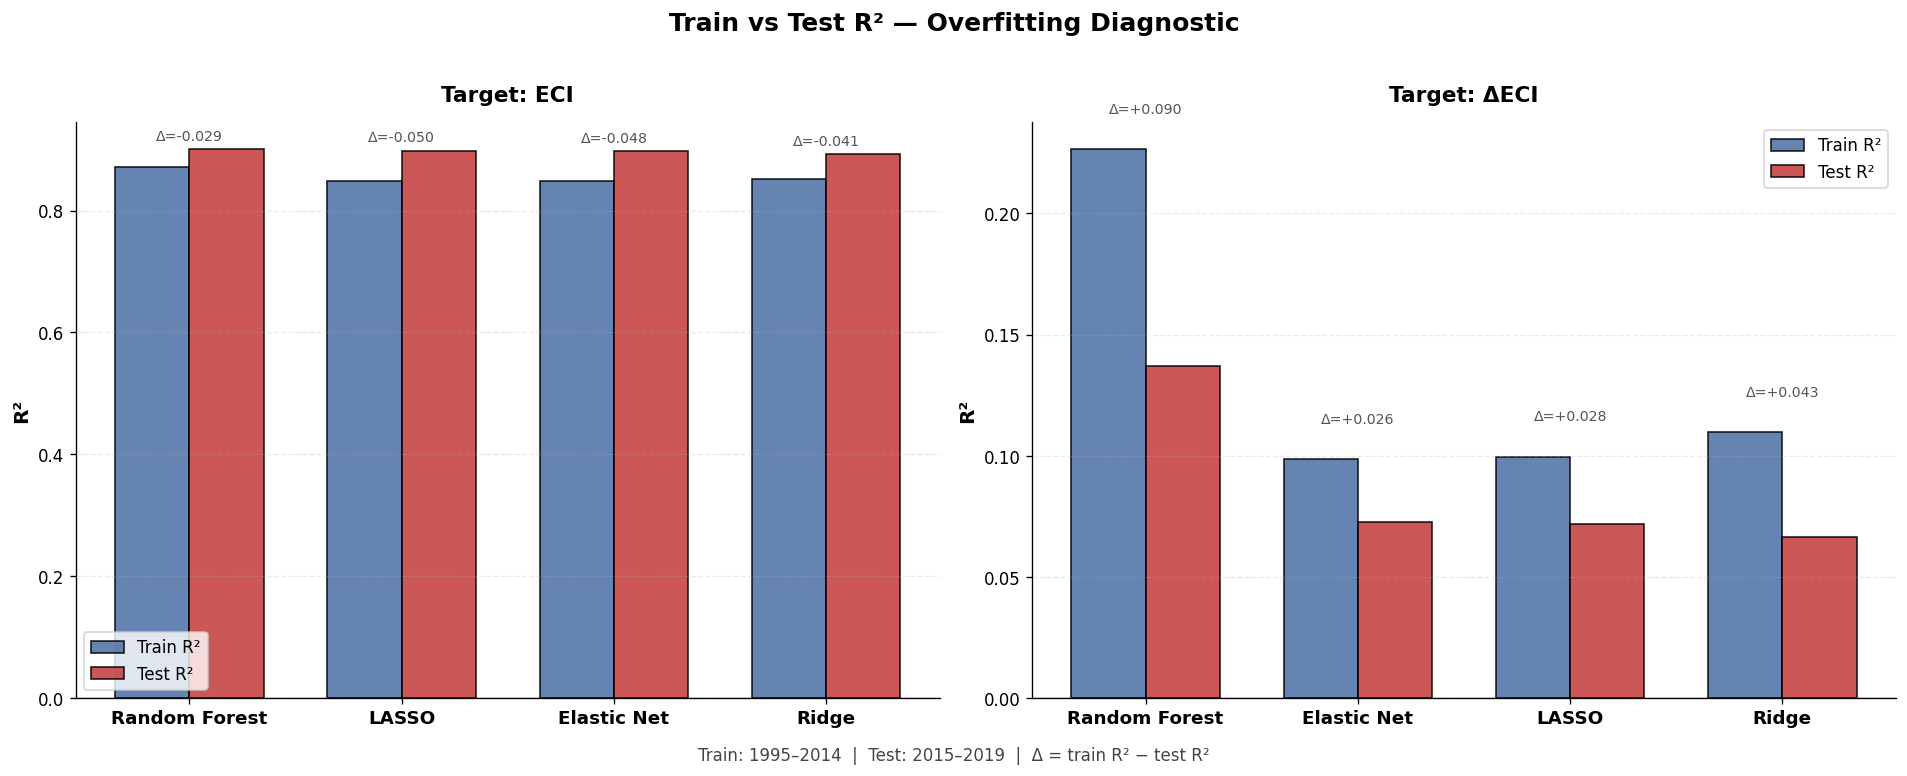

  ✓ Saved OOS_R2_comparison.{png,pdf}


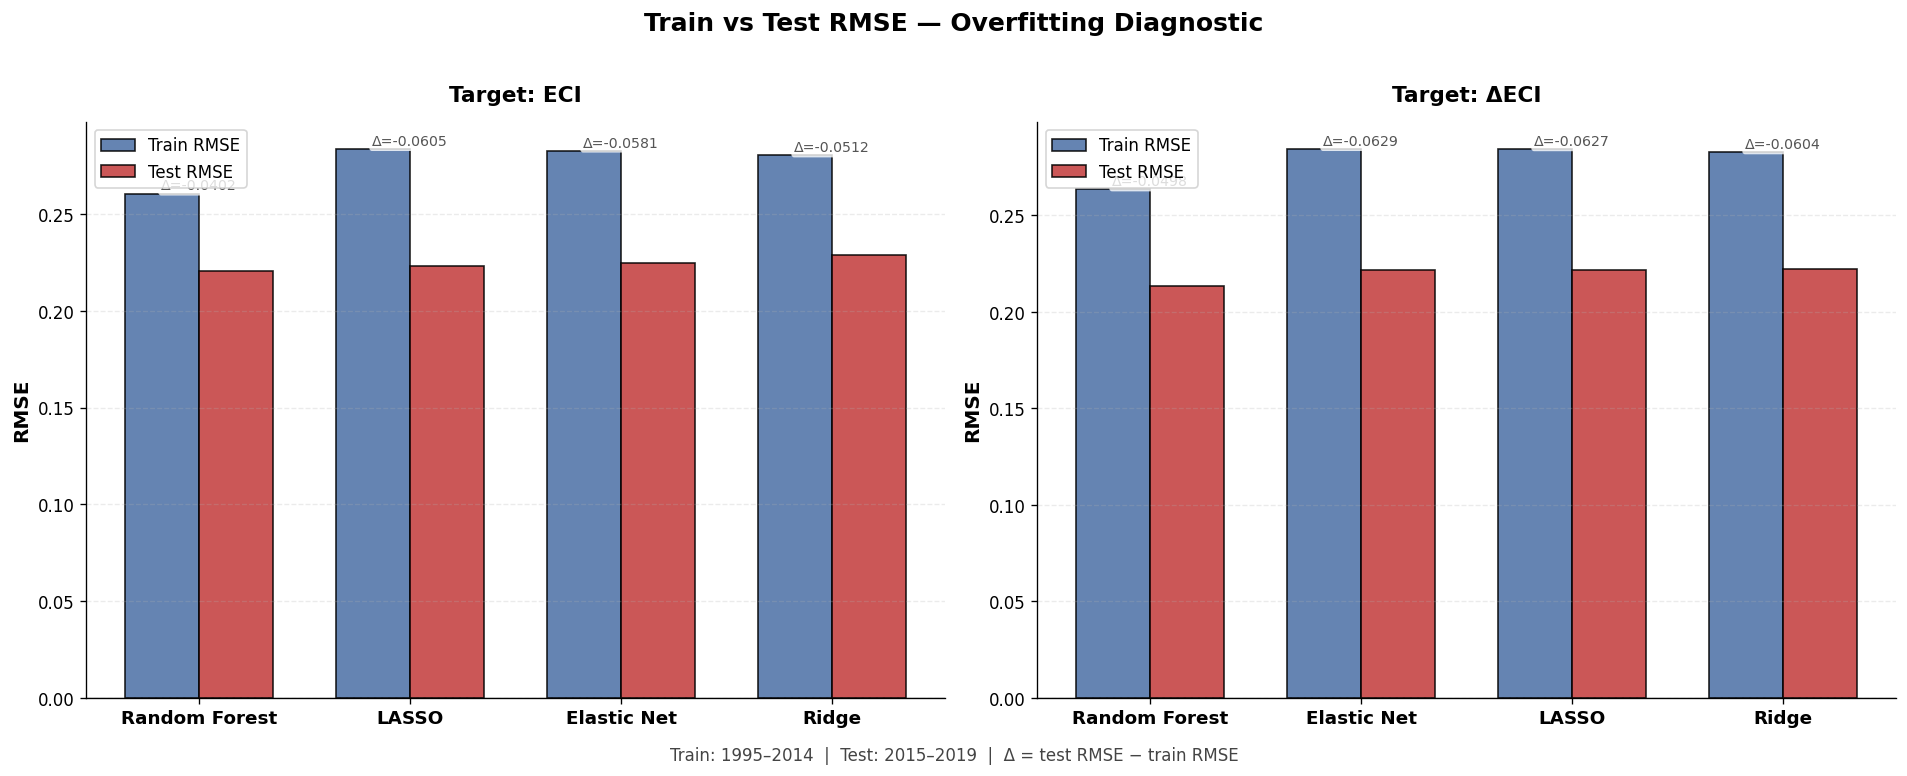

  ✓ Saved OOS_RMSE_comparison.{png,pdf}

[2/8] Predicted vs Actual (test set)...


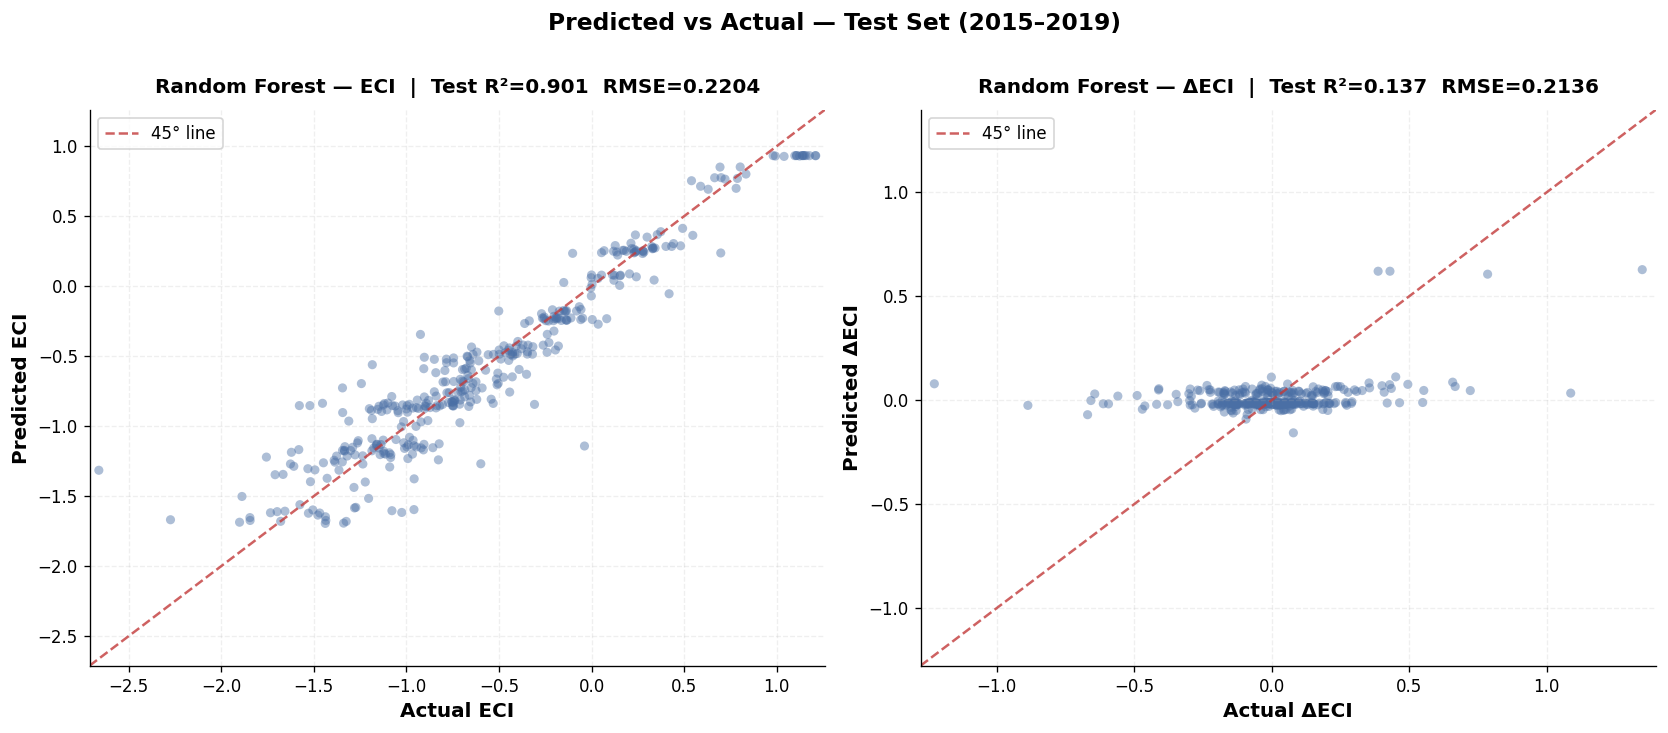

  ✓ Saved PredVsActual_test.{png,pdf}

[3/8] SHAP importance...


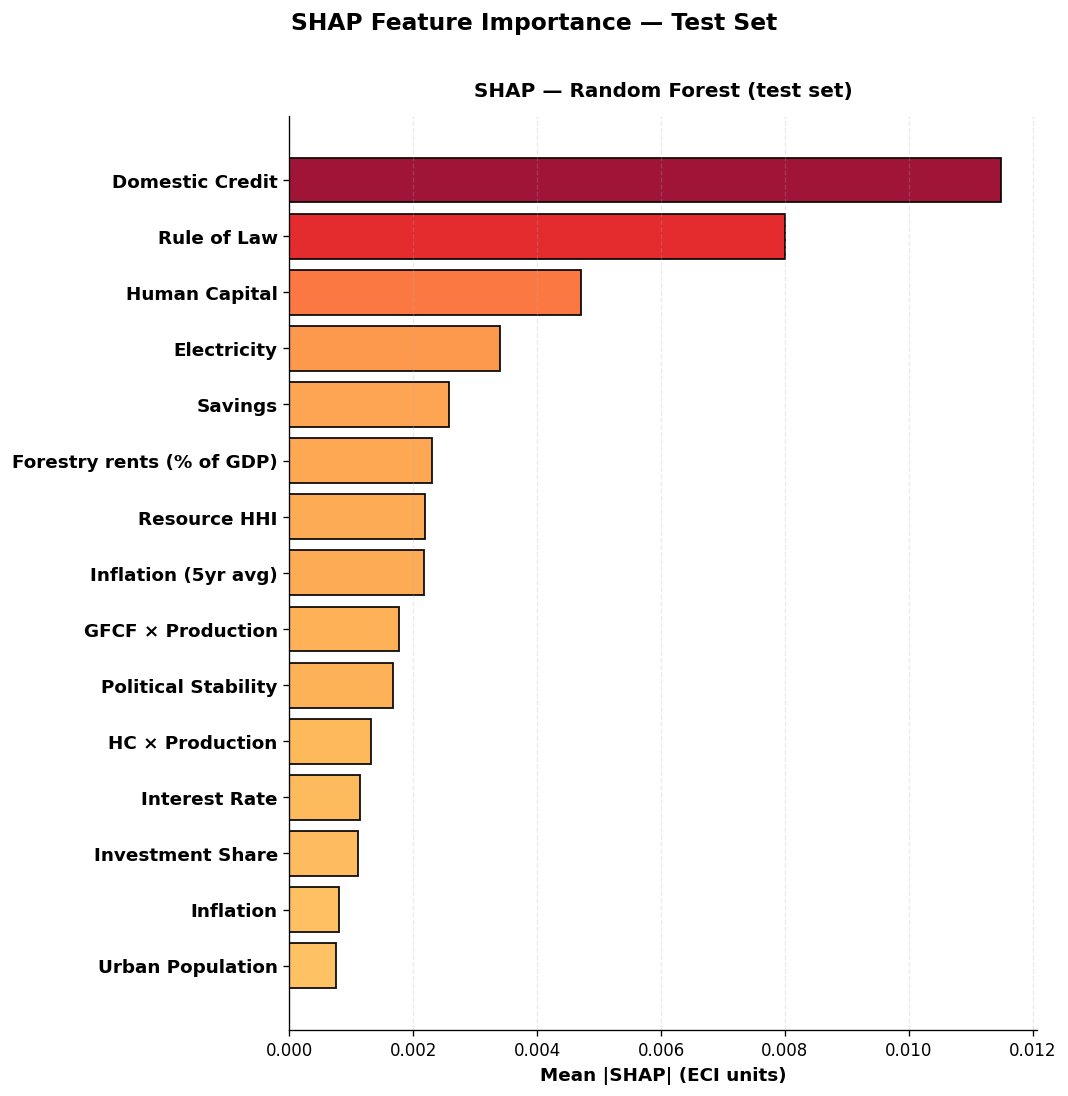

  ✓ Saved SHAP_importance.{png,pdf}

[4/8] Prediction intervals...


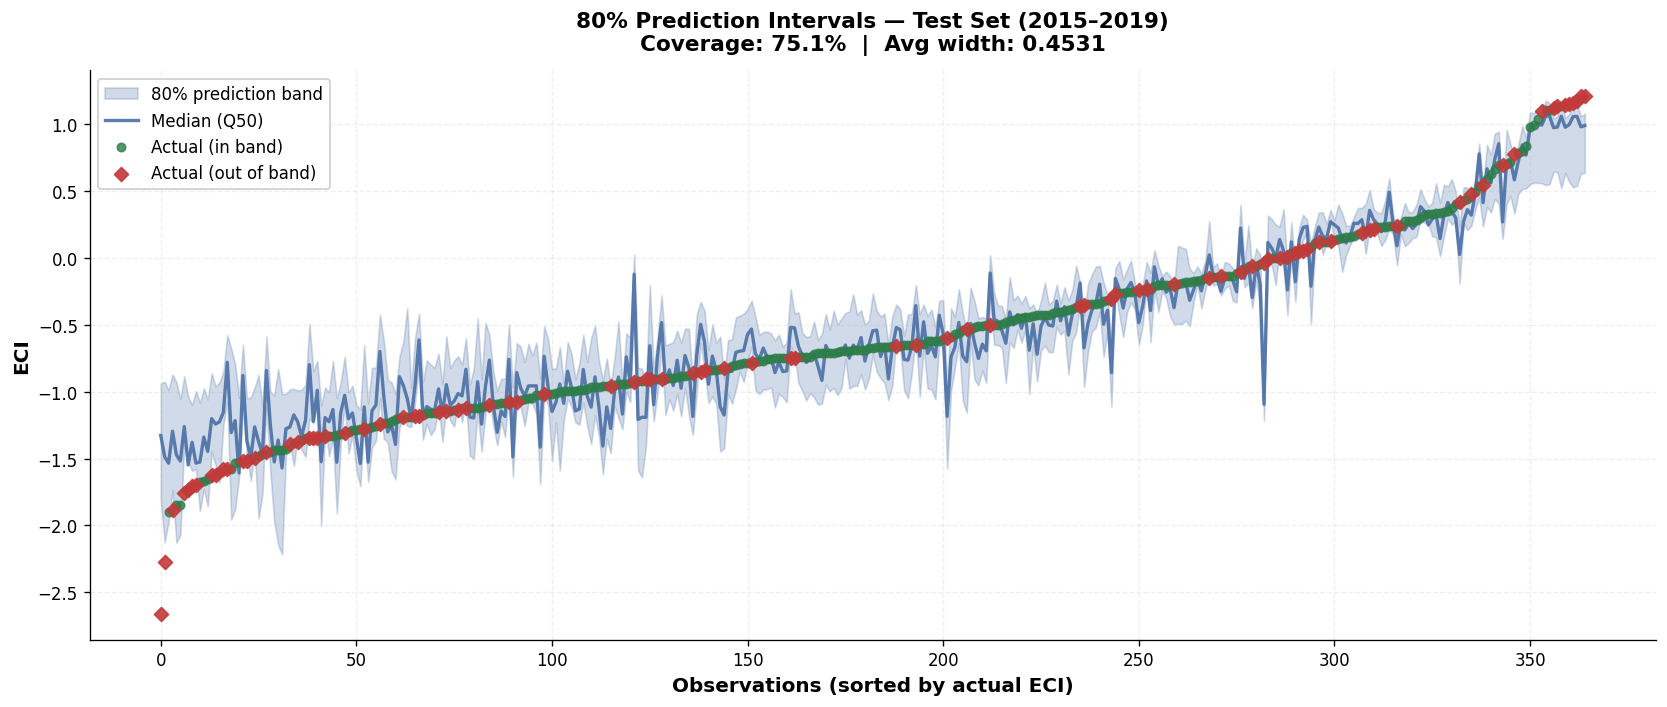

  ✓ Saved PredictionIntervals.{png,pdf}

[5/8] VIF chart...


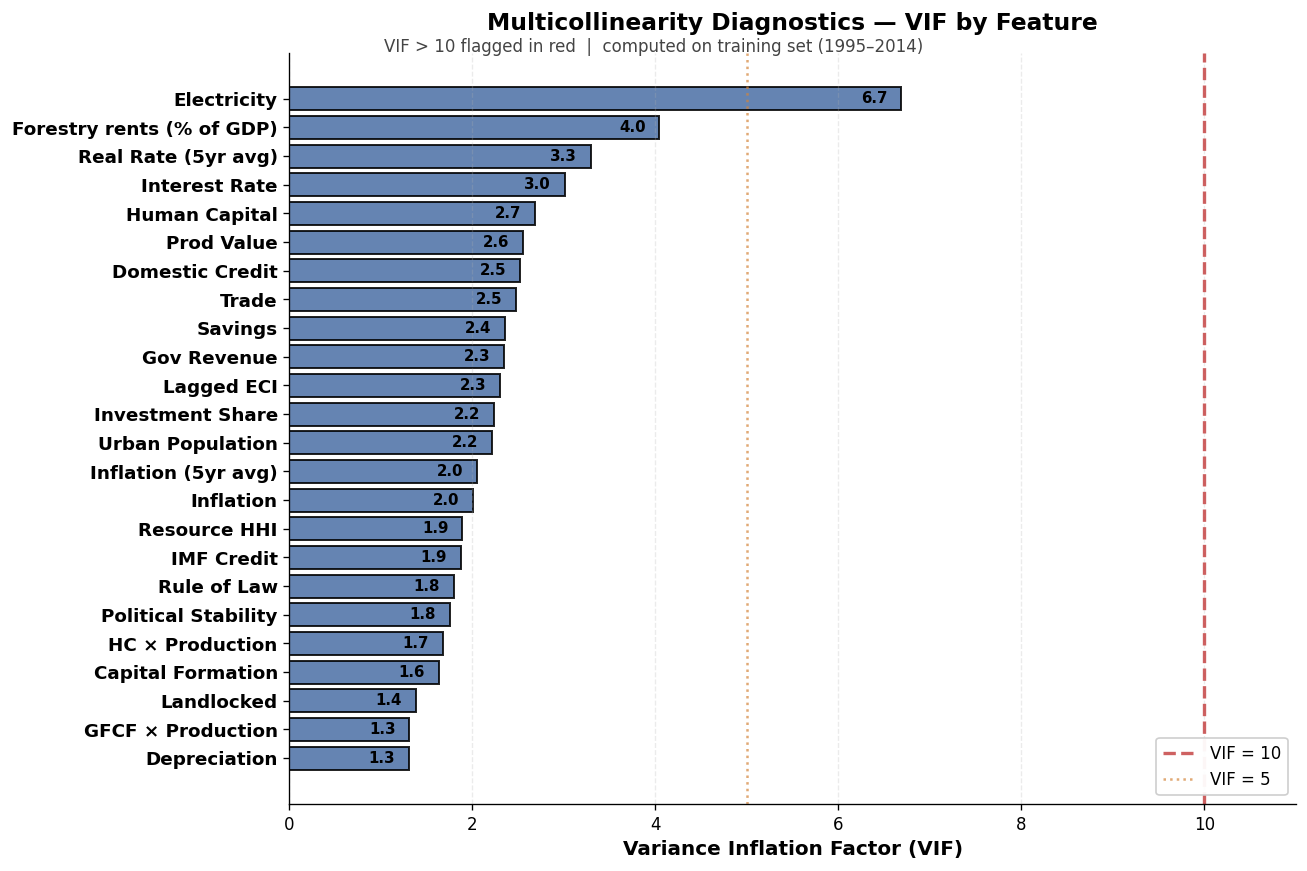

  ✓ Saved VIF_model2_resource_rich.{png,pdf}

[6/8] 3-panel coefficient comparison...


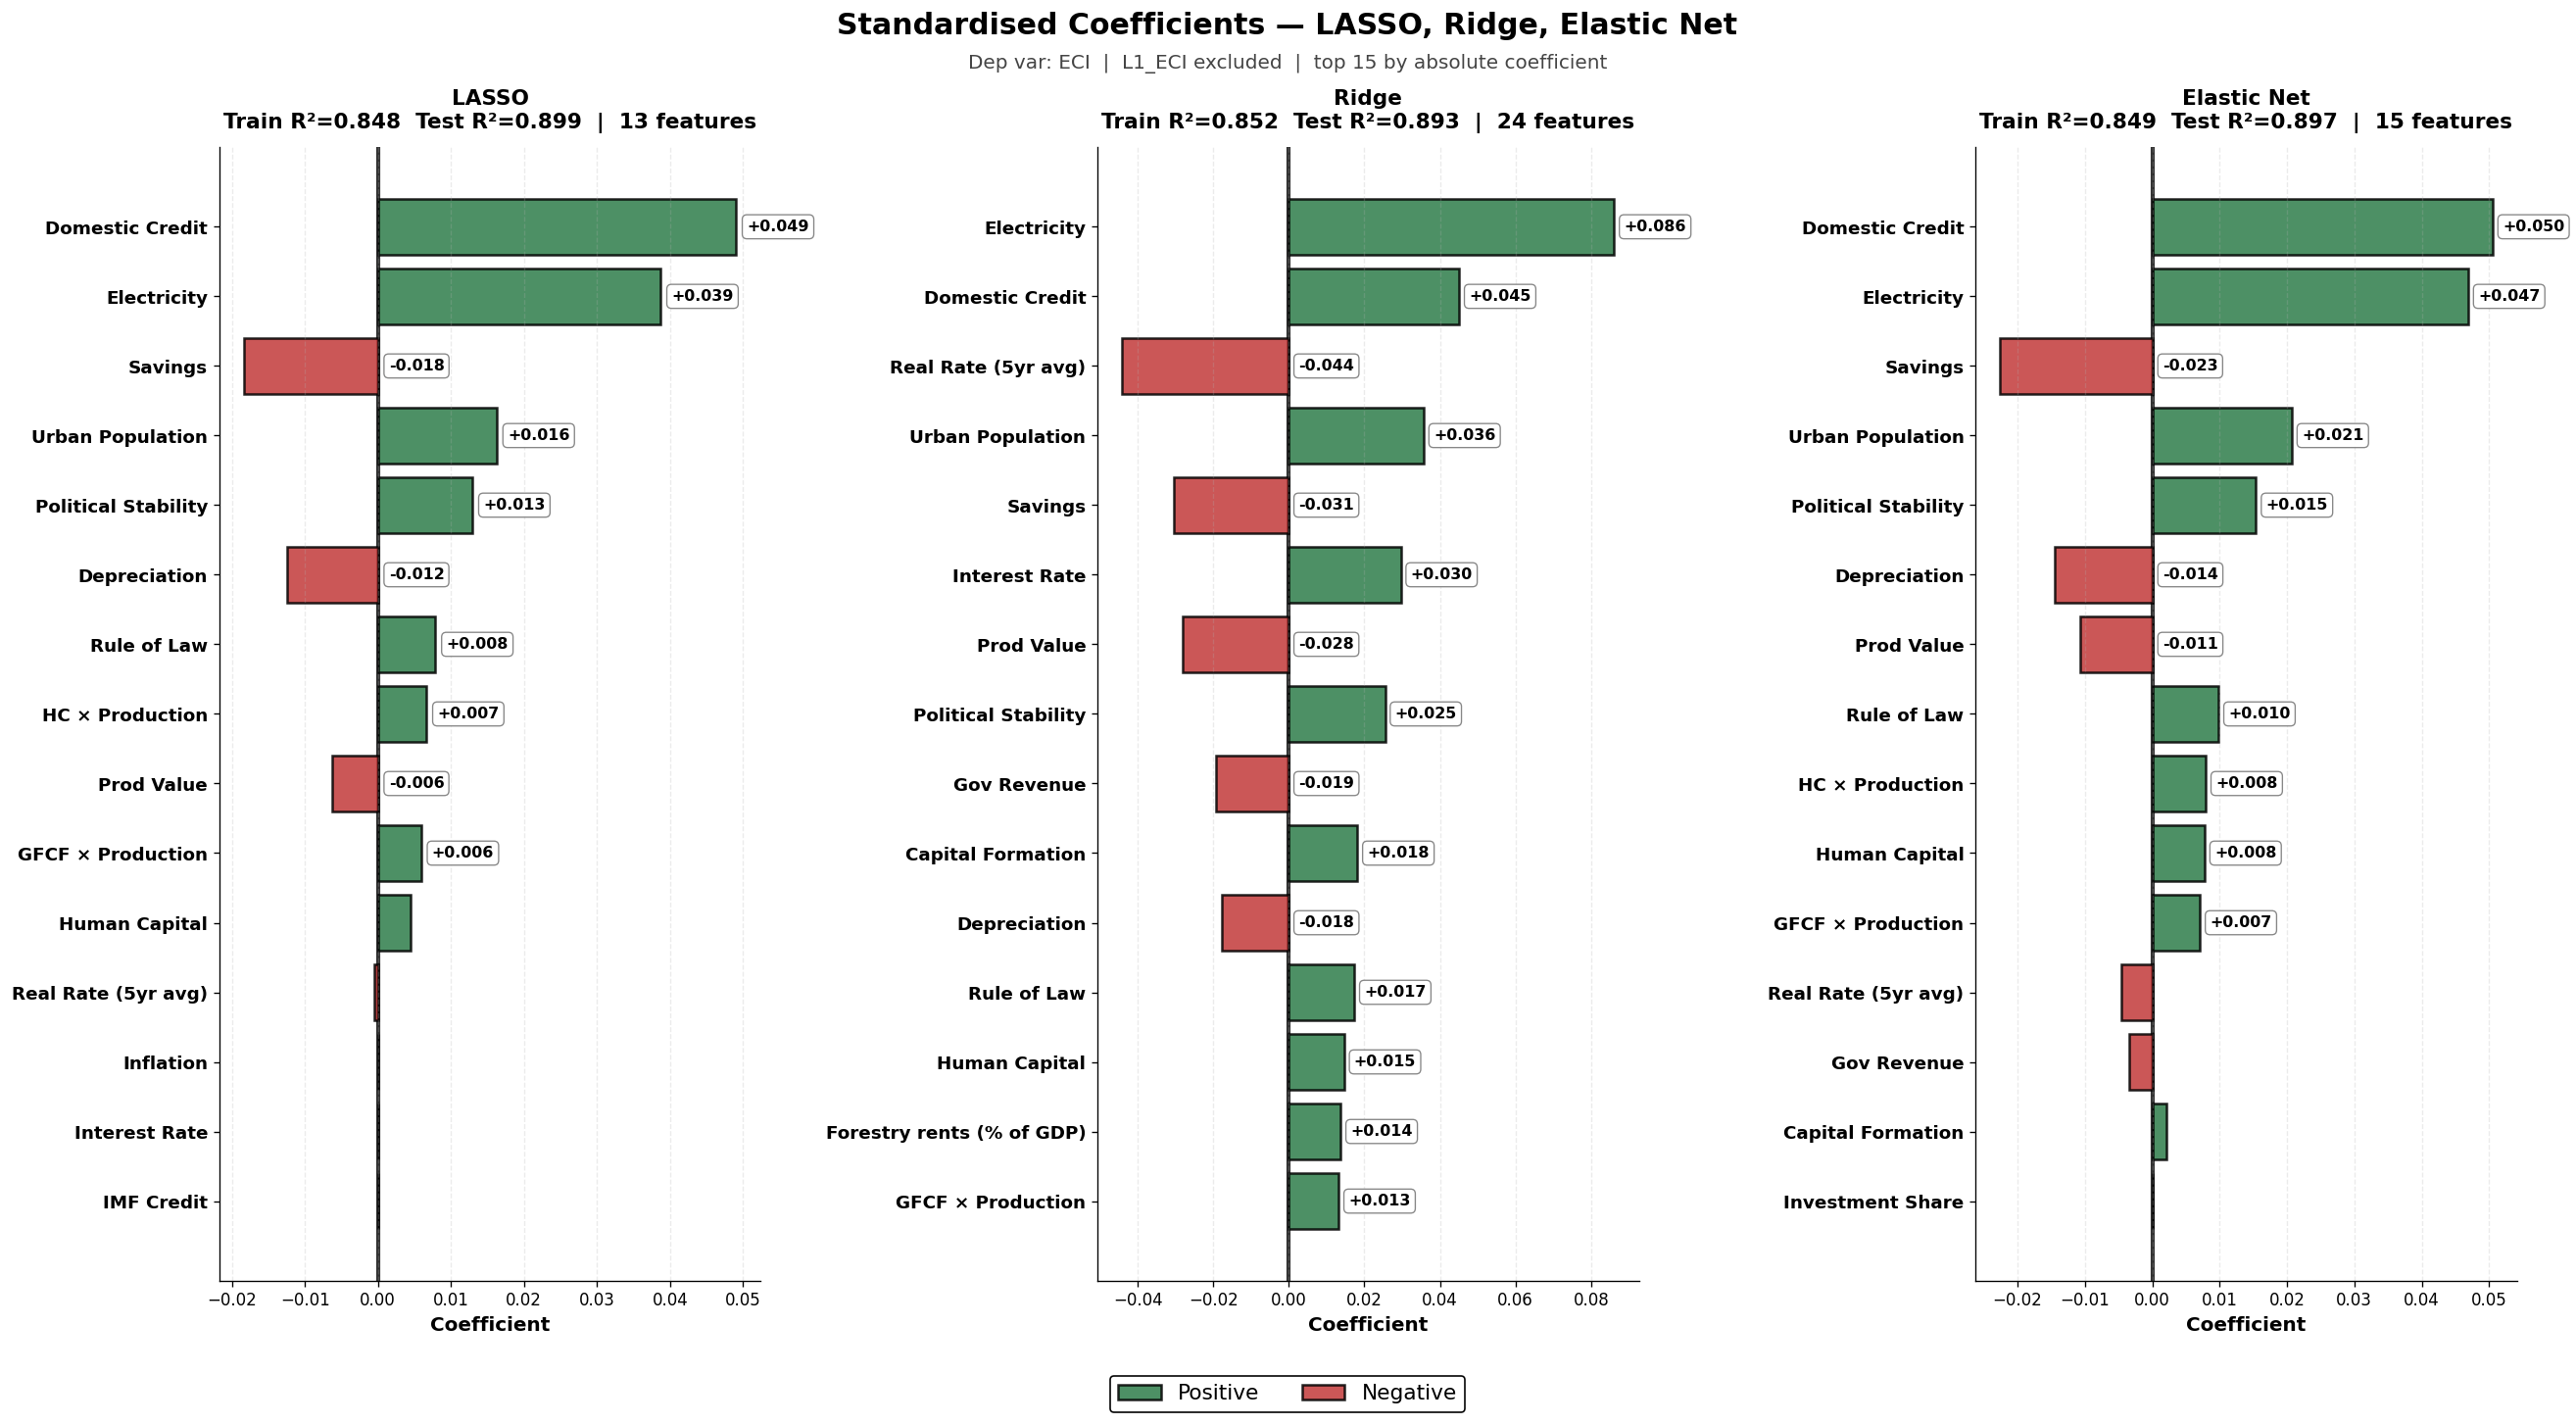

  ✓ Saved Coef_Comparison_model2_resource_rich.{png,pdf}

[7/8] Model agreement dot-and-range chart...


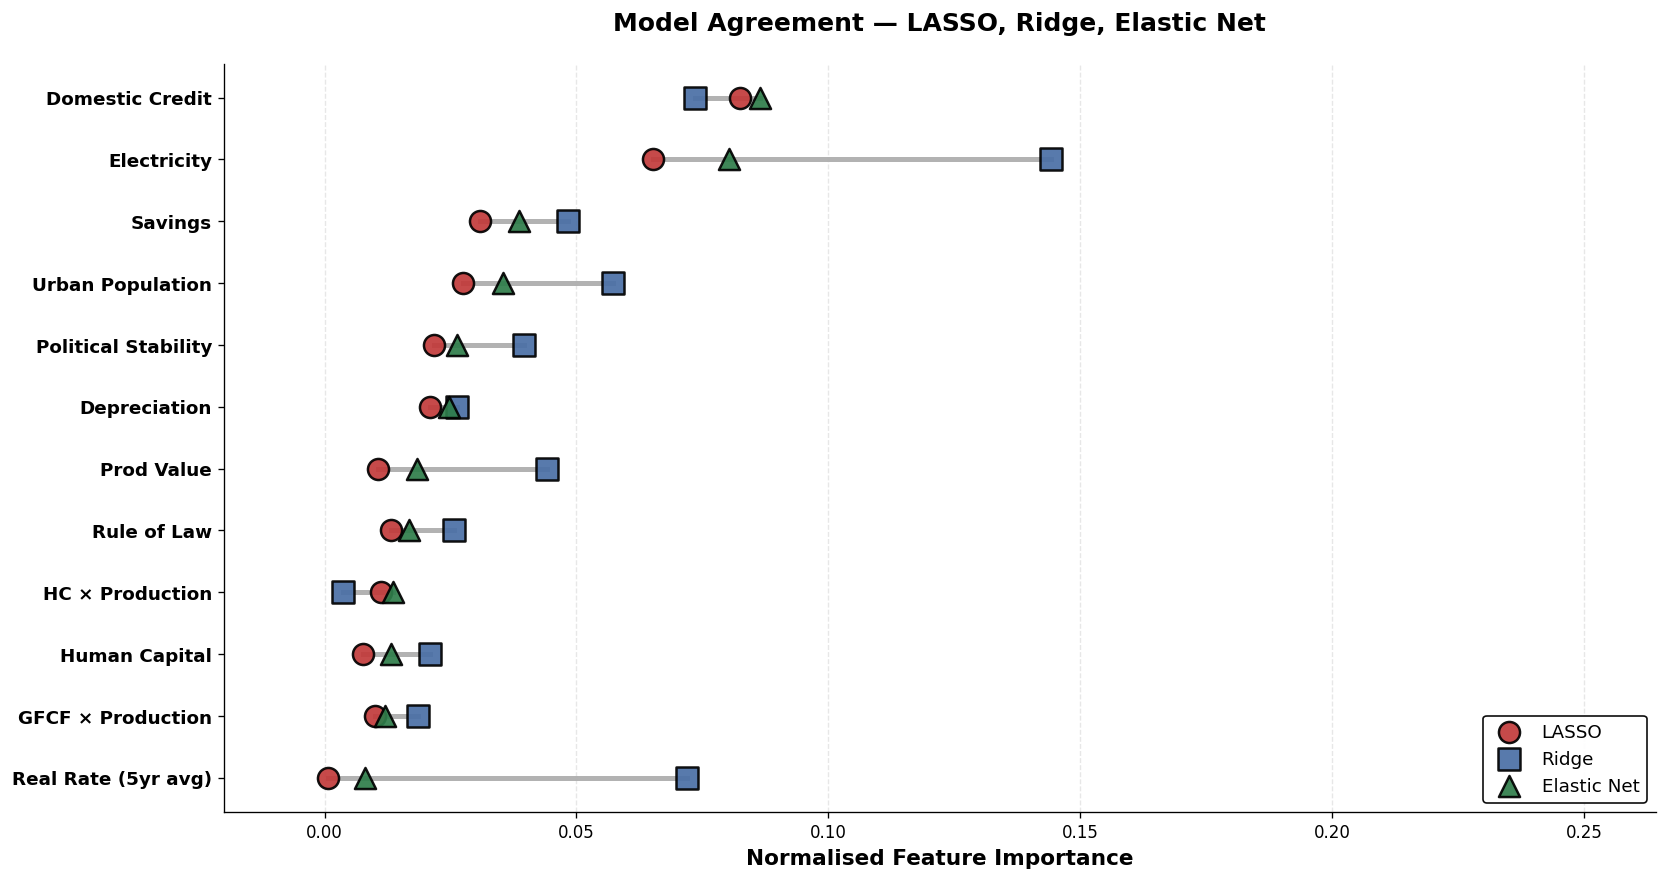

  ✓ Saved ModelAgreement_model2_resource_rich.{png,pdf}

[8/8] Random Forest importance...


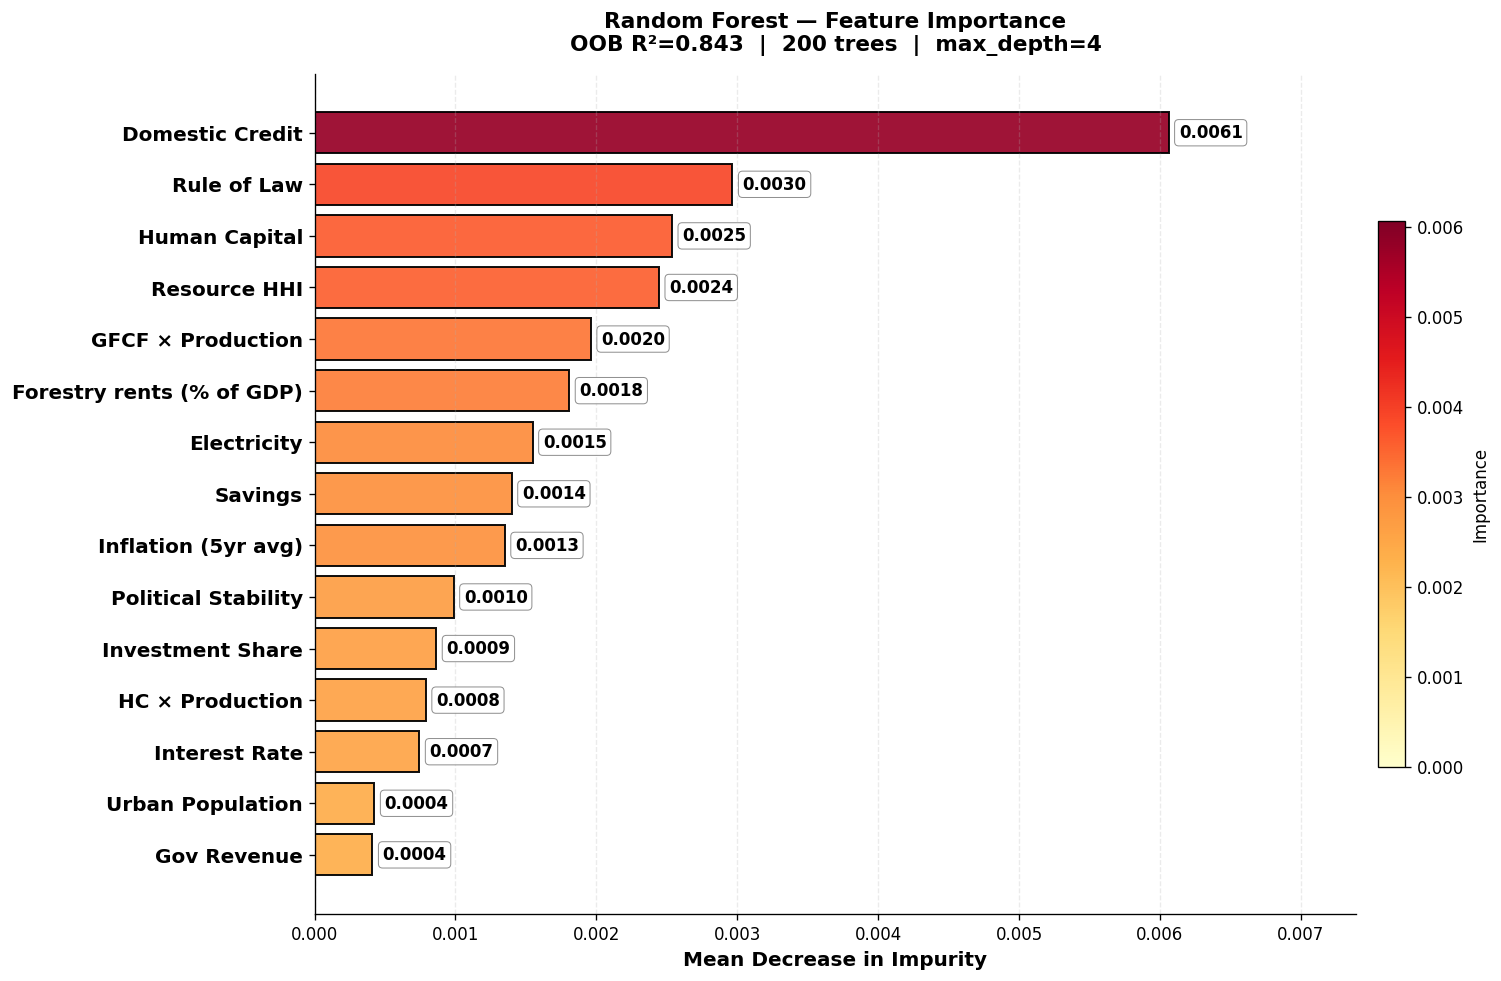

  ✓ Saved RF_model2_resource_rich.{png,pdf}

✓ All 8 static charts saved to Final/NB5/


In [6]:
# ── [1/8] Train vs Test R² ────────────────────────────────────────────────────
print("[1/8] Train vs Test R² comparison...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, perf, title in zip(axes,
                            [perf_level, perf_delta],
                            ['Target: ECI', 'Target: ΔECI']):
    model_names = perf['Model'].tolist()
    x = np.arange(len(model_names))
    w = 0.35
    ax.bar(x - w/2, perf['Train R²'], w, label='Train R²',
           color=PALETTE['blue'], alpha=0.85, edgecolor='black', linewidth=1)
    ax.bar(x + w/2, perf['Test R²'],  w, label='Test R²',
           color=PALETTE['red'],  alpha=0.85, edgecolor='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11, fontweight='bold')
    ax.set_ylabel('R²', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    for i, (tr, te) in enumerate(zip(perf['Train R²'], perf['Test R²'])):
        ax.text(i, max(tr, te) + 0.015, f'Δ={tr-te:+.3f}',
                ha='center', fontsize=8.5, color='#555',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle('Train vs Test R² — Overfitting Diagnostic', fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02, 'Train: 1995–2014  |  Test: 2015–2019  |  Δ = train R² − test R²',
            ha='center', fontsize=10, color='#444')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'OOS_R2_comparison.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'OOS_R2_comparison.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved OOS_R2_comparison.{png,pdf}")


# ── CHART 1b: Train vs Test RMSE ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, perf, title in zip(axes,
                            [perf_level, perf_delta],
                            ['Target: ECI', 'Target: ΔECI']):
    model_names = perf['Model'].tolist()
    x = np.arange(len(model_names))
    w = 0.35
    ax.bar(x - w/2, perf['Train RMSE'], w, label='Train RMSE',
           color=PALETTE['blue'], alpha=0.85, edgecolor='black', linewidth=1)
    ax.bar(x + w/2, perf['Test RMSE'],  w, label='Test RMSE',
           color=PALETTE['red'],  alpha=0.85, edgecolor='black', linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=11, fontweight='bold')
    ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.8, alpha=0.5)
    for i, (tr, te) in enumerate(zip(perf['Train RMSE'], perf['Test RMSE'])):
        ax.text(i, max(tr, te) + 0.002, f'Δ={te-tr:+.4f}',
                ha='center', fontsize=8.5, color='#555',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

plt.suptitle('Train vs Test RMSE — Overfitting Diagnostic', fontsize=15, fontweight='bold', y=1.02)
plt.figtext(0.5, -0.02, 'Train: 1995–2014  |  Test: 2015–2019  |  Δ = test RMSE − train RMSE',
            ha='center', fontsize=10, color='#444')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'OOS_RMSE_comparison.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'OOS_RMSE_comparison.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved OOS_RMSE_comparison.{png,pdf}")

# ── [2/8] Predicted vs Actual ─────────────────────────────────────────────────
print("\n[2/8] Predicted vs Actual (test set)...")

best_level = perf_level.iloc[0]['Model']
best_delta = perf_delta.iloc[0]['Model']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, actual, pred_vals, name, target in zip(
    axes,
    [y_test_level,  y_test_delta],
    [models_level[best_level].predict(X_test), models_delta[best_delta].predict(X_test)],
    [best_level,    best_delta],
    ['ECI',         'ΔECI'],
):
    r2_val   = r2_score(actual, pred_vals)
    rmse_val = np.sqrt(mean_squared_error(actual, pred_vals))
    ax.scatter(actual, pred_vals, alpha=0.45, s=30, color=PALETTE['blue'], edgecolor='none')
    lims = [min(actual.min(), pred_vals.min()) - 0.05,
            max(actual.max(), pred_vals.max()) + 0.05]
    ax.plot(lims, lims, '--', color=PALETTE['red'], linewidth=1.5, alpha=0.8, label='45° line')
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel(f'Actual {target}', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Predicted {target}', fontsize=12, fontweight='bold')
    ax.set_title(f'{name} — {target}  |  Test R²={r2_val:.3f}  RMSE={rmse_val:.4f}',
                 fontsize=12, fontweight='bold', pad=10)
    ax.legend(fontsize=10); ax.grid(alpha=0.2, linestyle='--')

plt.suptitle('Predicted vs Actual — Test Set (2015–2019)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'PredVsActual_test.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'PredVsActual_test.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved PredVsActual_test.{png,pdf}")


# ── [3/8] SHAP ────────────────────────────────────────────────────────────────
print("\n[3/8] SHAP importance...")
if HAS_SHAP and shap_results:
    n_panels = len(shap_results)
    fig, axes = plt.subplots(1, n_panels, figsize=(9 * n_panels, 9))
    if n_panels == 1: axes = [axes]
    for ax, (mname, sv) in zip(axes, shap_results.items()):
        mean_abs = np.abs(sv).mean(axis=0)
        feat_idx = [i for i, f in enumerate(all_features) if f != EXCLUDE]
        top15    = np.argsort(mean_abs[feat_idx])[-15:]
        vals_top = mean_abs[feat_idx][top15]
        names_top = [short_names[feat_idx[i]] for i in top15]
        cmap = plt.cm.YlOrRd
        colors = [cmap(0.3 + 0.65 * v / vals_top.max()) for v in vals_top]
        ax.barh(np.arange(len(top15)), vals_top, color=colors, edgecolor='black', linewidth=1.1, alpha=0.92)
        ax.set_yticks(np.arange(len(top15))); ax.set_yticklabels(names_top, fontsize=11, fontweight='bold')
        ax.set_xlabel('Mean |SHAP| (ECI units)', fontsize=11, fontweight='bold')
        ax.set_title(f'SHAP — {mname} (test set)', fontsize=12, fontweight='bold', pad=12)
        ax.grid(axis='x', alpha=0.25, linestyle='--')
    plt.suptitle('SHAP Feature Importance — Test Set', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, 'SHAP_importance.png'), dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(os.path.join(OUT, 'SHAP_importance.pdf'), bbox_inches='tight')
    plt.show()
    print("  ✓ Saved SHAP_importance.{png,pdf}")
else:
    print("  Skipped — SHAP not available")


# ── [4/8] Prediction intervals ────────────────────────────────────────────────
print("\n[4/8] Prediction intervals...")
plot_df = interval_df.sort_values('Actual').reset_index(drop=True)
x_idx   = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(x_idx, plot_df['Q10'], plot_df['Q90'],
                alpha=0.25, color=PALETTE['blue'], label='80% prediction band')
ax.plot(x_idx, plot_df['Q50'], color=PALETTE['blue'], linewidth=2,
        label='Median (Q50)', alpha=0.9)
ax.scatter(x_idx[plot_df['In_Band']],  plot_df.loc[plot_df['In_Band'],  'Actual'],
           color=PALETTE['green'], s=25, alpha=0.8, zorder=3, label='Actual (in band)')
ax.scatter(x_idx[~plot_df['In_Band']], plot_df.loc[~plot_df['In_Band'], 'Actual'],
           color=PALETTE['red'],   s=35, alpha=0.9, zorder=4, marker='D', label='Actual (out of band)')
ax.set_xlabel('Observations (sorted by actual ECI)', fontsize=12, fontweight='bold')
ax.set_ylabel('ECI', fontsize=12, fontweight='bold')
ax.set_title(f'80% Prediction Intervals — Test Set (2015–2019)\n'
             f'Coverage: {coverage:.1%}  |  Avg width: {avg_width:.4f}',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper left', framealpha=0.95)
ax.grid(alpha=0.2, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'PredictionIntervals.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'PredictionIntervals.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved PredictionIntervals.{png,pdf}")


# ── [5/8] VIF ─────────────────────────────────────────────────────────────────
print("\n[5/8] VIF chart...")
vif_plot = vif_data.copy()
vif_plot['Short'] = vif_plot['Feature'].apply(shorten)
vif_plot = vif_plot.sort_values('VIF', ascending=True).reset_index(drop=True)
bar_colors = [PALETTE['red'] if v > 10 else PALETTE['blue'] for v in vif_plot['VIF']]

fig, ax = plt.subplots(figsize=(11, 8))
y_pos = np.arange(len(vif_plot))
ax.barh(y_pos, vif_plot['VIF'], color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)
ax.axvline(10, color=PALETTE['red'],    linewidth=2,   linestyle='--', alpha=0.8, label='VIF = 10')
ax.axvline(5,  color=PALETTE['orange'], linewidth=1.5, linestyle=':',  alpha=0.7, label='VIF = 5')
ax.set_yticks(y_pos); ax.set_yticklabels(vif_plot['Short'], fontsize=11, fontweight='bold')
ax.set_xlabel('Variance Inflation Factor (VIF)', fontsize=12, fontweight='bold')
ax.set_title('Multicollinearity Diagnostics — VIF by Feature', fontsize=14, fontweight='bold', pad=14)
plt.figtext(0.5, 0.86, 'VIF > 10 flagged in red  |  computed on training set (1995–2014)',
            ha='center', fontsize=10, color='#444')
for i, val in enumerate(vif_plot['VIF']):
    ax.text(min(val - 0.15, 10.8), i, f'{val:.1f}',
            va='center', ha='right', fontsize=9, fontweight='bold', color='black')
ax.set_xlim(0, 11)
ax.legend(fontsize=10, loc='lower right', framealpha=0.95)
ax.grid(axis='x', alpha=0.25, linestyle='--')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(OUT, 'VIF_model2_resource_rich.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'VIF_model2_resource_rich.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved VIF_model2_resource_rich.{png,pdf}")


# ── [6/8] 3-Panel Coefficient Comparison ──────────────────────────────────────
print("\n[6/8] 3-panel coefficient comparison...")
fig, axes = plt.subplots(1, 3, figsize=(22, 12))
for idx, mname in enumerate(['LASSO', 'Ridge', 'Elastic Net']):
    ax = axes[idx]
    coef_vals = models_level[mname].coef_.copy()
    abs_vals  = np.abs(coef_vals)
    excl_idx  = all_features.index(EXCLUDE) if EXCLUDE in all_features else None
    if excl_idx is not None: abs_vals[excl_idx] = -np.inf
    top15_idx  = np.argsort(abs_vals)[::-1][:15]
    top15_vals = coef_vals[top15_idx]
    colors     = [PALETTE['green'] if v > 0 else PALETTE['red'] for v in top15_vals]
    y_pos      = np.arange(len(top15_idx))
    ax.barh(y_pos, top15_vals, color=colors, alpha=0.85, edgecolor='black', linewidth=1.5)
    ax.axvline(0, color='black', linewidth=2.5, alpha=0.8, zorder=0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([shorten(all_features[i]) for i in top15_idx], fontsize=11, fontweight='bold')
    ax.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
    ax.invert_yaxis(); ax.grid(axis='x', alpha=0.25, linestyle='--')
    r2_tr = perf_level[perf_level['Model'] == mname]['Train R²'].values[0]
    r2_te = perf_level[perf_level['Model'] == mname]['Test R²'].values[0]
    n_sel = int(np.sum(models_level[mname].coef_ != 0))
    ax.set_title(f'{mname}\nTrain R²={r2_tr:.3f}  Test R²={r2_te:.3f}  |  {n_sel} features',
                 fontsize=13, fontweight='bold', pad=12)
    x_max = max(abs(top15_vals)) if len(top15_vals) else 1
    for i, val in enumerate(top15_vals):
        if abs(val) > 0.005:
            ax.text(abs(val) + x_max*0.03 if val > 0 else x_max*0.03, i, f'{val:+.3f}',
                    va='center', ha='left', fontsize=9.5, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.95, edgecolor='gray', linewidth=0.8))

fig.legend(handles=[Patch(facecolor=PALETTE['green'], label='Positive', alpha=0.85, edgecolor='black', linewidth=1.5),
                    Patch(facecolor=PALETTE['red'],   label='Negative', alpha=0.85, edgecolor='black', linewidth=1.5)],
           loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, fontsize=13, framealpha=0.98, edgecolor='black')
plt.suptitle('Standardised Coefficients — LASSO, Ridge, Elastic Net', fontsize=18, fontweight='bold', y=0.98)
plt.figtext(0.5, 0.94, 'Dep var: ECI  |  L1_ECI excluded  |  top 15 by absolute coefficient',
            ha='center', fontsize=12, color='#444')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(os.path.join(OUT, 'Coef_Comparison_model2_resource_rich.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'Coef_Comparison_model2_resource_rich.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved Coef_Comparison_model2_resource_rich.{png,pdf}")


# ── [7/8] Model Agreement ─────────────────────────────────────────────────────
print("\n[7/8] Model agreement dot-and-range chart...")
imp_df = all_importance[all_importance['Feature'] != EXCLUDE].copy()
top12  = imp_df.sort_values('Elastic Net', ascending=False).head(12).reset_index(drop=True)
top12['Short'] = top12['Feature'].apply(shorten)
fig, ax = plt.subplots(figsize=(14, 8))
y_pos = np.arange(len(top12))
for i, row in top12.iterrows():
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net']]
    ax.plot([min(vals), max(vals)], [i, i], color='#555555', alpha=0.45, linewidth=3, zorder=1)
    ax.scatter(row['LASSO'],       i, marker='o', s=160, alpha=0.92, color=PALETTE['red'],   edgecolor='black', linewidth=1.5, zorder=3, label='LASSO'       if i == 0 else '')
    ax.scatter(row['Ridge'],       i, marker='s', s=160, alpha=0.92, color=PALETTE['blue'],  edgecolor='black', linewidth=1.5, zorder=3, label='Ridge'       if i == 0 else '')
    ax.scatter(row['Elastic Net'], i, marker='^', s=160, alpha=0.92, color=PALETTE['green'], edgecolor='black', linewidth=1.5, zorder=3, label='Elastic Net' if i == 0 else '')
ax.set_yticks(y_pos); ax.set_yticklabels(top12['Short'], fontsize=11, fontweight='bold')
ax.set_xlabel('Normalised Feature Importance', fontsize=13, fontweight='bold')
ax.set_title('Model Agreement — LASSO, Ridge, Elastic Net', fontsize=15, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.legend(fontsize=11, loc='lower right', framealpha=0.95, edgecolor='black')
ax.grid(axis='x', alpha=0.3, linestyle='--')
x_max_val = max(top12[['LASSO', 'Ridge', 'Elastic Net']].max())
ax.set_xlim(-0.02, x_max_val + 0.12)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(os.path.join(OUT, 'ModelAgreement_model2_resource_rich.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'ModelAgreement_model2_resource_rich.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved ModelAgreement_model2_resource_rich.{png,pdf}")


# ── [8/8] Random Forest ───────────────────────────────────────────────────────
print("\n[8/8] Random Forest importance...")
rf_imp = pd.DataFrame({'Feature': all_features, 'Importance': rf.feature_importances_})
rf_top = (rf_imp[rf_imp['Feature'] != EXCLUDE]
          .sort_values('Importance', ascending=False).head(15).reset_index(drop=True))
norm_vals  = rf_top['Importance'] / rf_top['Importance'].max()
cmap       = plt.cm.YlOrRd
bar_colors = [cmap(0.35 + 0.60 * v) for v in norm_vals]
fig, ax = plt.subplots(figsize=(13, 9))
y_pos = np.arange(len(rf_top))
ax.barh(y_pos, rf_top['Importance'], color=bar_colors, edgecolor='black', linewidth=1.2, alpha=0.92)
ax.set_yticks(y_pos); ax.set_yticklabels([shorten(f) for f in rf_top['Feature']], fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity', fontsize=12, fontweight='bold')
ax.invert_yaxis(); ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.set_xlim(right=rf_top['Importance'].max() * 1.22)
x_max_rf = rf_top['Importance'].max()
for i, val in enumerate(rf_top['Importance']):
    ax.text(val + x_max_rf*0.012, i, f'{val:.4f}', va='center', ha='left', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.88, edgecolor='gray', linewidth=0.6))
ax.set_title(f'Random Forest — Feature Importance\nOOB R²={rf.oob_score_:.3f}  |  200 trees  |  max_depth=4',
             fontsize=13, fontweight='bold', pad=14)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=x_max_rf))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.025, pad=0.02)
cbar.set_label('Importance', fontsize=10)
plt.tight_layout(rect=[0, 0, 0.97, 0.92])
plt.savefig(os.path.join(OUT, 'RF_model2_resource_rich.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'RF_model2_resource_rich.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved RF_model2_resource_rich.{png,pdf}")
print(f"\n✓ All 8 static charts saved to {OUT}/")

## 6. Visualisations — Interactive (Plotly)

Five interactive charts matching the static charts above.

In [7]:
# ── [A] Train vs Test R² ─────────────────────────────────────────────────────
print("[A] OOS R² comparison...")
figA = make_subplots(rows=1, cols=2, subplot_titles=['Target: ECI', 'Target: ΔECI'],
                     horizontal_spacing=0.1)
for col, perf in enumerate([perf_level, perf_delta], 1):
    figA.add_trace(go.Bar(name='Train R²', x=perf['Model'], y=perf['Train R²'],
                          marker_color=PALETTE['blue'], opacity=0.85,
                          text=[f'{v:.3f}' for v in perf['Train R²']], textposition='outside',
                          showlegend=(col==1)), row=1, col=col)
    figA.add_trace(go.Bar(name='Test R²',  x=perf['Model'], y=perf['Test R²'],
                          marker_color=PALETTE['red'],  opacity=0.85,
                          text=[f'{v:.3f}' for v in perf['Test R²']],  textposition='outside',
                          showlegend=(col==1)), row=1, col=col)
    figA.update_yaxes(title_text='R²' if col==1 else '',
                      gridcolor=STYLE['grid_color'], row=1, col=col)
figA.update_layout(**base_layout(barmode='group', height=STYLE['chart_height'],
                                  legend=dict(orientation='h', y=-0.15, x=0.5, xanchor='center',
                                              font=dict(size=STYLE['legend_size'])),
                                  margin=dict(l=60, r=40, t=80, b=80)))
save_chart(figA, os.path.join(OUT, 'OOS_R2_interactive'))


# ── [B] Prediction intervals ──────────────────────────────────────────────────
print("\n[B] Prediction intervals...")
plot_s  = interval_df.sort_values('Actual').reset_index(drop=True)
xlabels = plot_s.apply(lambda r: f"{r['Country Code']} {int(r['Year'])}", axis=1)

figB = go.Figure()
figB.add_trace(go.Scatter(
    x=list(range(len(plot_s))) + list(range(len(plot_s)))[::-1],
    y=plot_s['Q90'].tolist() + plot_s['Q10'].tolist()[::-1],
    fill='toself', fillcolor='rgba(74,111,165,0.2)',
    line=dict(color='rgba(0,0,0,0)'), hoverinfo='skip', name='80% band'))
figB.add_trace(go.Scatter(x=list(range(len(plot_s))), y=plot_s['Q50'],
    mode='lines', line=dict(color=PALETTE['blue'], width=2), name='Median (Q50)'))
for mask, color, sym, lbl in [
    (plot_s['In_Band'],  PALETTE['green'], 'circle',  'In band'),
    (~plot_s['In_Band'], PALETTE['red'],   'diamond', 'Out of band'),
]:
    figB.add_trace(go.Scatter(
        x=plot_s.index[mask].tolist(), y=plot_s.loc[mask, 'Actual'],
        mode='markers', marker=dict(color=color, size=7 if lbl=='In band' else 9, symbol=sym, opacity=0.85),
        name=f'Actual ({lbl})',
        hovertemplate='%{text}<br>Actual: %{y:.3f}<extra></extra>',
        text=xlabels[mask].tolist()))
figB.update_layout(**base_layout(
    xaxis=dict(title='Observations (sorted by actual)', showticklabels=False,
               gridcolor=STYLE['grid_color']),
    yaxis=dict(title='ECI', gridcolor=STYLE['grid_color']),
    annotations=[dict(text=f"Coverage: {coverage:.1%}  |  Avg width: {avg_width:.4f}",
                      xref='paper', yref='paper', x=0.01, y=0.99, showarrow=False,
                      font=dict(size=11, color='#555'),
                      bgcolor='rgba(250,250,250,0.9)', bordercolor='#ddd', borderwidth=1, borderpad=6)],
    legend=dict(font=dict(size=STYLE['legend_size']), bgcolor='rgba(250,250,250,0.9)',
                bordercolor='#e5e7eb', borderwidth=1)))
save_chart(figB, os.path.join(OUT, 'PredictionIntervals_interactive'))


# ── [C] VIF interactive ───────────────────────────────────────────────────────
print("\n[C] VIF chart (interactive)...")
vif_plot = vif_data.copy()
vif_plot['Short'] = vif_plot['Feature'].apply(shorten)
vif_plot = vif_plot.sort_values('VIF', ascending=True).reset_index(drop=True)
colors_vif = [PALETTE['red'] if v > 10 else PALETTE['blue'] for v in vif_plot['VIF']]

figC = go.Figure(go.Bar(
    y=vif_plot['Short'], x=vif_plot['VIF'], orientation='h',
    marker=dict(color=colors_vif, line=dict(color='#1a2744', width=0.5)),
    text=[f'{v:.1f}' for v in vif_plot['VIF']], textposition='outside',
    textfont=dict(size=STYLE['annotation_size'], color=STYLE['title_color']),
))
figC.add_vline(x=10, line=dict(color=PALETTE['red'],    width=2,   dash='dash'),
               annotation_text='VIF = 10', annotation_position='right',
               annotation_font=dict(size=STYLE['annotation_size'], color=PALETTE['red']))
figC.add_vline(x=5,  line=dict(color=PALETTE['orange'], width=1.5, dash='dot'),
               annotation_text='VIF = 5',  annotation_position='right',
               annotation_font=dict(size=STYLE['annotation_size'], color=PALETTE['orange']))
figC.update_layout(**base_layout(height=STYLE['chart_height_tall'], margin=STYLE['margin_bar'],
                                  xaxis=dict(title=dict(text='Variance Inflation Factor',
                                                        font=dict(size=STYLE['axis_title_size'])),
                                             gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
                                             range=[0, max(vif_plot['VIF'].max()*1.15, 12)]),
                                  yaxis=dict(tickfont=dict(size=STYLE['tick_size'])),
                                  showlegend=False))
save_chart(figC, os.path.join(OUT, 'VIF_model2_resource_rich_interactive'), width=1100, height=700)


# ── [D] Model Agreement interactive ──────────────────────────────────────────
print("\n[D] Model agreement (interactive)...")
top12_r = top12.iloc[::-1].reset_index(drop=True)
figD = go.Figure()
for _, row in top12_r.iterrows():
    vals = [row['LASSO'], row['Ridge'], row['Elastic Net']]
    figD.add_trace(go.Scatter(x=[min(vals), max(vals)], y=[row['Short'], row['Short']],
                               mode='lines', line=dict(color='#aab0b8', width=3),
                               showlegend=False, hoverinfo='skip'))
for mname, sym, col in [('LASSO','circle',PALETTE['red']),('Ridge','square',PALETTE['blue']),('Elastic Net','triangle-up',PALETTE['green'])]:
    figD.add_trace(go.Scatter(x=top12_r[mname], y=top12_r['Short'], mode='markers',
                               marker=dict(symbol=sym, size=12, color=col, line=dict(color='#1a2744', width=1)),
                               name=mname, hovertemplate='%{y}: %{x:.3f}<extra>' + mname + '</extra>'))
figD.update_layout(**base_layout(height=STYLE['chart_height'], margin=STYLE['margin_bar'],
                                  xaxis=dict(title=dict(text='Normalised Feature Importance',
                                                        font=dict(size=STYLE['axis_title_size'])),
                                             gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
                                             range=[-0.02, top12[['LASSO','Ridge','Elastic Net']].max().max()+0.08]),
                                  yaxis=dict(tickfont=dict(size=STYLE['tick_size'])),
                                  legend=dict(font=dict(size=STYLE['legend_size']),
                                              yanchor='bottom', y=0.02, xanchor='right', x=0.98,
                                              bgcolor='rgba(250,250,250,0.95)', bordercolor='#e5e7eb', borderwidth=1)))
save_chart(figD, os.path.join(OUT, 'ModelAgreement_model2_resource_rich_interactive'), width=1100, height=600)


# ── [E] RF importance interactive ─────────────────────────────────────────────
print("\n[E] RF importance (interactive)...")
def lerp_color(t, c_lo=(230,185,128), c_hi=(180,80,40)):
    return f'rgb({int(c_lo[0]+(c_hi[0]-c_lo[0])*t)},{int(c_lo[1]+(c_hi[1]-c_lo[1])*t)},{int(c_lo[2]+(c_hi[2]-c_lo[2])*t)})'

rf_top_r       = rf_top.iloc[::-1].reset_index(drop=True)
norm_vals_r    = (rf_top_r['Importance'] / rf_top_r['Importance'].max()).values
bar_colors_rf  = [lerp_color(v) for v in norm_vals_r]

figE = go.Figure(go.Bar(
    y=[shorten(f) for f in rf_top_r['Feature']], x=rf_top_r['Importance'], orientation='h',
    marker=dict(color=bar_colors_rf, line=dict(color='#1a2744', width=0.5)),
    text=[f'{v:.4f}' for v in rf_top_r['Importance']], textposition='outside',
    textfont=dict(size=STYLE['annotation_size'], color=STYLE['title_color']),
))
figE.update_layout(**base_layout(height=STYLE['chart_height_tall'], margin=STYLE['margin_bar'],
                                  xaxis=dict(title=dict(text='Mean Decrease in Impurity',
                                                        font=dict(size=STYLE['axis_title_size'])),
                                             gridcolor=STYLE['grid_color'], gridwidth=STYLE['grid_width'],
                                             range=[0, rf_top['Importance'].max()*1.22]),
                                  yaxis=dict(tickfont=dict(size=STYLE['tick_size'])),
                                  showlegend=False,
                                  annotations=[dict(text=f"OOB R²={rf.oob_score_:.3f}  |  200 trees  |  max_depth=4",
                                                    xref='paper', yref='paper', x=0.98, y=0.02,
                                                    showarrow=False, font=dict(size=STYLE['annotation_size'], color='#666'),
                                                    bgcolor='rgba(250,250,250,0.95)', bordercolor='#e5e7eb',
                                                    borderwidth=1, borderpad=6)]))
save_chart(figE, os.path.join(OUT, 'RF_model2_resource_rich_interactive'), width=1100, height=700)
print(f"\n✓ All interactive charts saved to {OUT}/")

[A] OOS R² comparison...


  ✓ Final/NB5/OOS_R2_interactive.html


  ✓ Final/NB5/OOS_R2_interactive.png (kaleido)

[B] Prediction intervals...


  ✓ Final/NB5/PredictionIntervals_interactive.html


  ✓ Final/NB5/PredictionIntervals_interactive.png (kaleido)

[C] VIF chart (interactive)...


...

  ✓ Final/NB5/VIF_model2_resource_rich_interactive.png (kaleido)

[D] Model agreement (interactive)...


  ✓ Final/NB5/ModelAgreement_model2_resource_rich_interactive.html


  ✓ Final/NB5/ModelAgreement_model2_resource_rich_interactive.png (kaleido)

[E] RF importance (interactive)...


  ✓ Final/NB5/RF_model2_resource_rich_interactive.html


  ✓ Final/NB5/RF_model2_resource_rich_interactive.png (kaleido)

✓ All interactive charts saved to Final/NB5/


## 7. Coefficient Summary Table

Heatmap-style table: signed coefficients, normalised importance, VIF, and selection flags
for LASSO and Elastic Net.

  ✓ Final/NB5/coefficient_summary_table.csv

Feature                     LASSO    Ridge    E-Net   L-Imp   R-Imp  EN-Imp    VIF  L-Sel EN-Sel
───────────────────────────────────────────────────────────────────────────────────────────────
Domestic Credit            +0.049   +0.045   +0.050   0.083   0.074   0.086   2.52      ✓      ✓
Electricity                +0.039   +0.086   +0.047   0.065   0.144   0.080   6.69      ✓      ✓
Savings                    -0.018   -0.031   -0.023   0.031   0.048   0.039   2.36      ✓      ✓
Urban Population           +0.016   +0.036   +0.021   0.027   0.057   0.035   2.21      ✓      ✓
Political Stability        +0.013   +0.025   +0.015   0.022   0.040   0.026   1.75      ✓      ✓
Depreciation               -0.012   -0.018   -0.014   0.021   0.026   0.025   1.31      ✓      ✓
Prod Value                 -0.006   -0.028   -0.011   0.011   0.044   0.018   2.56      ✓      ✓
Rule of Law                +0.008   +0.017   +0.010   0.013   0.026   0.017   1.79 

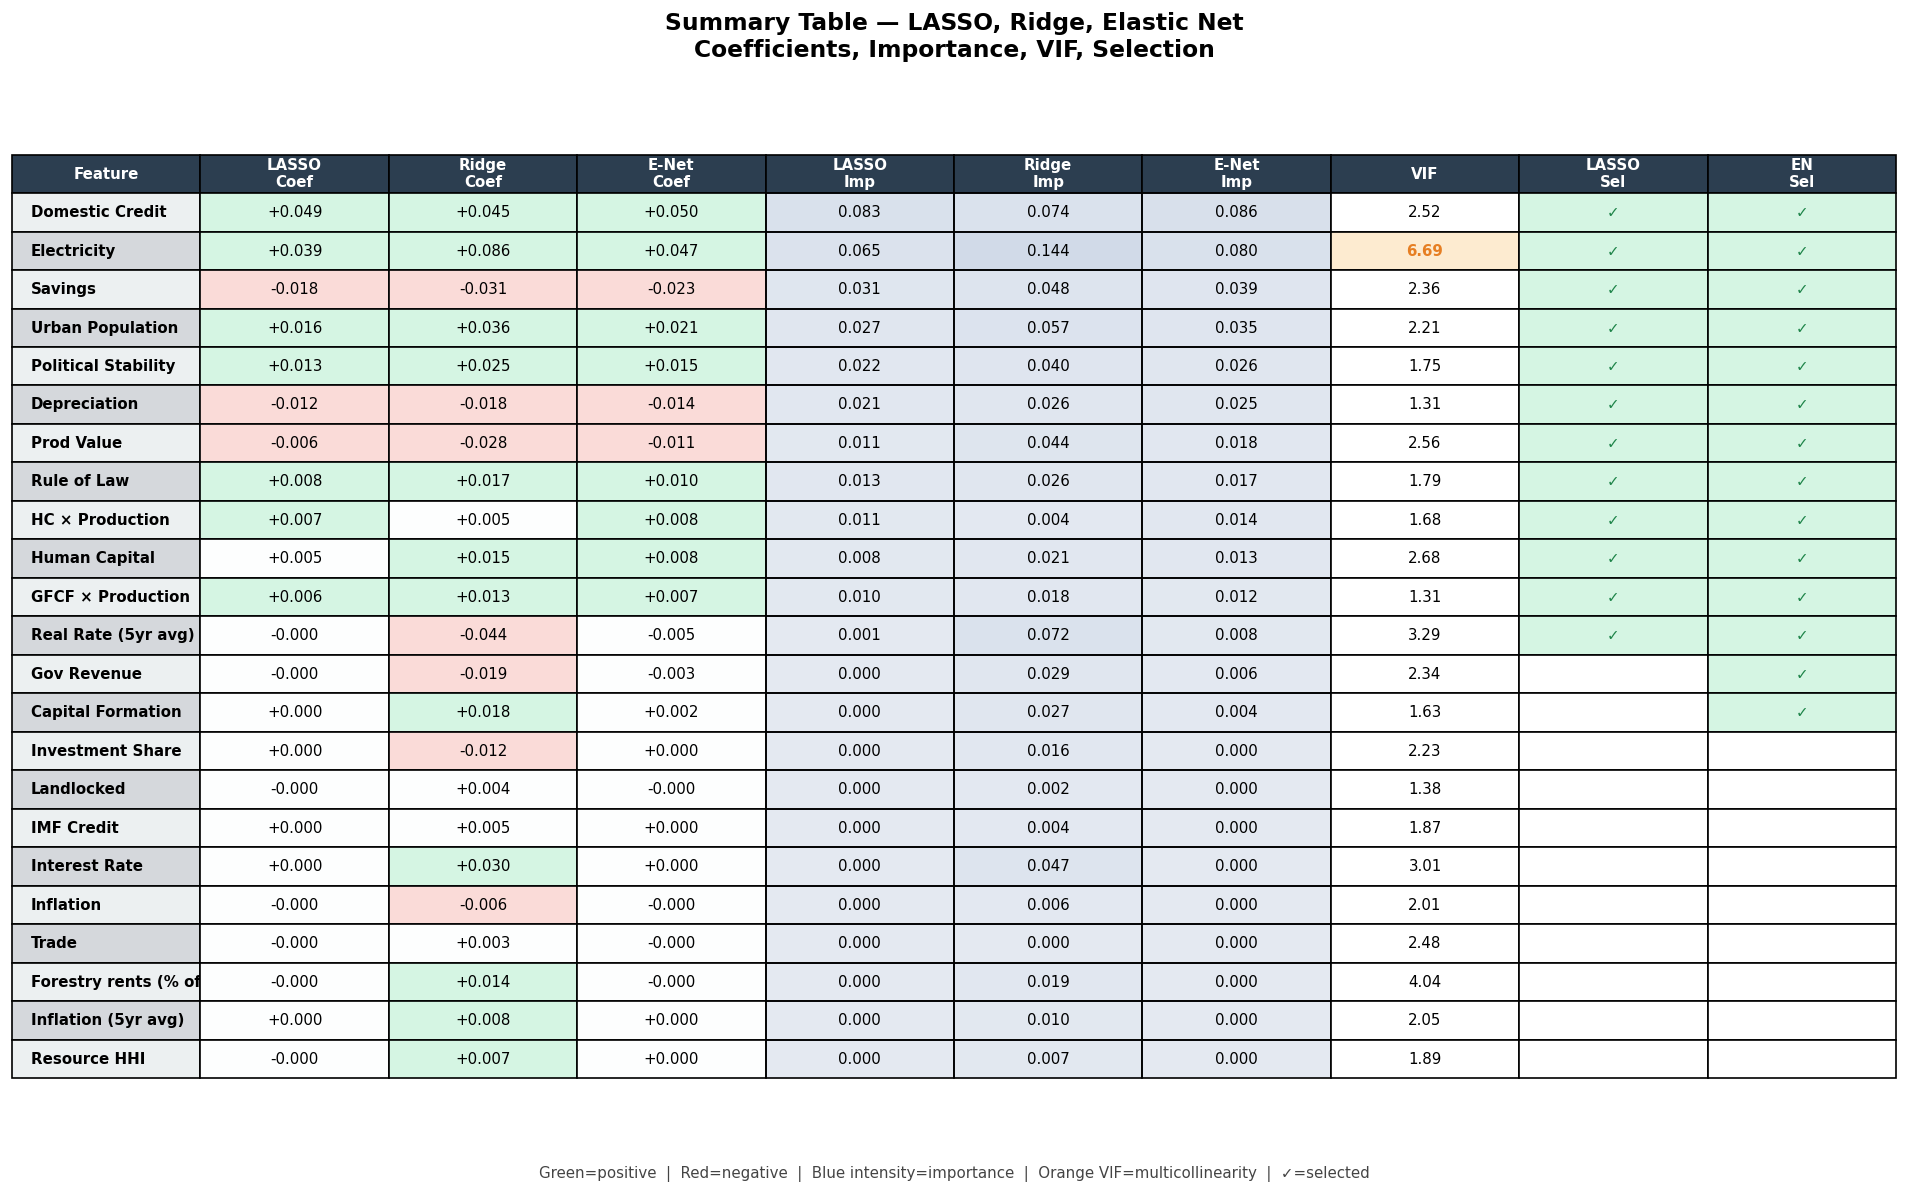

  ✓ Saved SummaryTable_model2_resource_rich.{png,pdf}


In [8]:
# ── Build table ───────────────────────────────────────────────────────────────
table = pd.DataFrame({'Feature': all_features})
for mname, model in lin_models.items():
    table[mname] = model.coef_
for mname in ['LASSO', 'Ridge', 'Elastic Net']:
    table[f'{mname}_Imp'] = all_importance.set_index('Feature')[mname].reindex(all_features).values
table = table.merge(vif_data, on='Feature')
table['LASSO_Selected']       = (table['LASSO']       != 0).astype(int)
table['Elastic Net_Selected'] = (table['Elastic Net'] != 0).astype(int)
table = (table[table['Feature'] != EXCLUDE]
         .assign(sort_key=lambda d: d['Elastic Net'].abs())
         .sort_values('sort_key', ascending=False)
         .drop(columns='sort_key')
         .reset_index(drop=True))
table['Feature'] = table['Feature'].apply(shorten)
table.to_csv(os.path.join(OUT, 'coefficient_summary_table.csv'), index=False)
print(f"  ✓ {OUT}/coefficient_summary_table.csv")

# ── Console summary ────────────────────────────────────────────────────────────
print(f"\n{'Feature':<24} {'LASSO':>8} {'Ridge':>8} {'E-Net':>8} "
      f"{'L-Imp':>7} {'R-Imp':>7} {'EN-Imp':>7} {'VIF':>6} {'L-Sel':>6} {'EN-Sel':>6}")
print("─" * 95)
for _, row in table.iterrows():
    print(f"{row['Feature']:<24} {row['LASSO']:>+8.3f} {row['Ridge']:>+8.3f} {row['Elastic Net']:>+8.3f} "
          f"{row['LASSO_Imp']:>7.3f} {row['Ridge_Imp']:>7.3f} {row['Elastic Net_Imp']:>7.3f} "
          f"{row['VIF']:>6.2f} {'✓' if row['LASSO_Selected'] else '':>6} {'✓' if row['Elastic Net_Selected'] else '':>6}")

# ── Heatmap chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')
col_labels = ['Feature', 'LASSO\nCoef', 'Ridge\nCoef', 'E-Net\nCoef',
              'LASSO\nImp', 'Ridge\nImp', 'E-Net\nImp', 'VIF', 'LASSO\nSel', 'EN\nSel']
cell_vals = [[
    row['Feature'], f"{row['LASSO']:+.3f}", f"{row['Ridge']:+.3f}", f"{row['Elastic Net']:+.3f}",
    f"{row['LASSO_Imp']:.3f}", f"{row['Ridge_Imp']:.3f}", f"{row['Elastic Net_Imp']:.3f}",
    f"{row['VIF']:.2f}", '✓' if row['LASSO_Selected'] else '', '✓' if row['Elastic Net_Selected'] else '',
] for _, row in table.iterrows()]

tbl = ax.table(cellText=cell_vals, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1.0, 1.6)
for col_idx in range(len(col_labels)):
    tbl[0, col_idx].set_facecolor('#2C3E50')
    tbl[0, col_idx].set_text_props(color='white', fontweight='bold', fontsize=9)
for row_idx, (_, row) in enumerate(table.iterrows(), start=1):
    tbl[row_idx, 0].set_facecolor('#ECF0F1' if row_idx % 2 else '#D5D8DC')
    tbl[row_idx, 0].set_text_props(fontweight='bold', ha='left')
    for ci, cn in [(1,'LASSO'),(2,'Ridge'),(3,'Elastic Net')]:
        val = row[cn]
        tbl[row_idx, ci].set_facecolor('#D5F5E3' if val > 0.005 else '#FADBD8' if val < -0.005 else '#FDFEFE')
    for ci, cn in [(4,'LASSO_Imp'),(5,'Ridge_Imp'),(6,'Elastic Net_Imp')]:
        alpha = 0.15 + 0.70 * row[cn]
        tbl[row_idx, ci].set_facecolor(mcolors.to_rgba(PALETTE['blue'], alpha=alpha))
    vif_val = row['VIF']
    if vif_val > 10:
        tbl[row_idx, 7].set_facecolor('#FADBD8'); tbl[row_idx, 7].set_text_props(color='#C0392B', fontweight='bold')
    elif vif_val > 5:
        tbl[row_idx, 7].set_facecolor('#FDEBD0'); tbl[row_idx, 7].set_text_props(color='#E67E22', fontweight='bold')
    for ci, sc in [(8,'LASSO_Selected'),(9,'Elastic Net_Selected')]:
        if row[sc]:
            tbl[row_idx, ci].set_facecolor('#D5F5E3'); tbl[row_idx, ci].set_text_props(color='#1E8449', fontweight='bold')

ax.set_title('Summary Table — LASSO, Ridge, Elastic Net\nCoefficients, Importance, VIF, Selection',
             fontsize=14, fontweight='bold', pad=16, y=0.98)
plt.figtext(0.5, 0.01, 'Green=positive  |  Red=negative  |  Blue intensity=importance  |  Orange VIF=multicollinearity  |  ✓=selected',
            ha='center', fontsize=9, color='#444')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'SummaryTable_model2_resource_rich.png'), dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(os.path.join(OUT, 'SummaryTable_model2_resource_rich.pdf'), bbox_inches='tight')
plt.show()
print("  ✓ Saved SummaryTable_model2_resource_rich.{png,pdf}")

## 8. Forecast 2020–2030 & Country Rankings

**Strategy:**
1. Retrain all models on the full 1995–2019 sample.
2. Extrapolate features using the last-5-year linear trend per country.
3. Predict iteratively (each year's L1_ECI = prior year's prediction).
4. Ensemble = mean of all level and accumulated-Δ predictions.

Results are saved to `Graphics/NB5/ECI_Forecast_2020_2030.csv` and
`Graphics/NB5/Country_Ranking_2020_2030.csv`.

In [9]:
# ── Retrain on full 1995–2019 sample ──────────────────────────────────────────
X_full_raw    = df[all_features].values
y_full_level  = df['Economic Complexity Index'].values

scaler_full = StandardScaler()
X_full      = scaler_full.fit_transform(X_full_raw)

full_years = df['Year'].values
tscv_full  = PanelTemporalCV(full_years, n_splits=5, gap=1, min_train_years=8)

models_full_level = fit_all_models(X_full, y_full_level, tscv_full,
                                   label='ECI (full)', years=full_years)
print("\n✓ All models retrained on full 1995–2019 sample.")

# ── Build future feature rows by linear extrapolation ────────────────────────
FORECAST_YEARS = list(range(2020, 2031))
trend_features = [f for f in base_features if f not in ['L1_ECI', 'Landlocked']] + new_features

def extrapolate_country(country_df, years):
    last5 = country_df.tail(5)
    rows = []
    for yr in years:
        row = {'Year': yr, 'Country Code': country_df['Country Code'].iloc[0],
               'Country Name': country_df['Country Name'].iloc[0]}
        for feat in trend_features:
            vals = last5[feat].dropna().values
            if len(vals) >= 2:
                x_t = np.arange(len(vals))
                slope, intercept = np.polyfit(x_t, vals, 1)
                steps = yr - int(last5['Year'].iloc[-1])
                row[feat] = float(intercept + slope * (len(vals) - 1 + steps))
            else:
                row[feat] = float(last5[feat].iloc[-1]) if len(vals) == 1 else 0.0
        row['Landlocked'] = float(country_df['Landlocked'].iloc[0])
        rows.append(row)
    return rows

future_rows = []
for cc, cdf in df.groupby('Country Code'):
    future_rows.extend(extrapolate_country(cdf, FORECAST_YEARS))
future_df = pd.DataFrame(future_rows)

# ── Forecast uncertainty note ────────────────────────────────────────────────
# This forecast uses linear extrapolation of features over 11 years (2020-2030)
# from the last 5 observed data points. Key limitations:
#   1. Features like IMF credit, inflation, or political stability can reverse
#      sharply — a linear trend assumption is strong over this horizon.
#   2. The iterative loop compounds errors: each year's L1_ECI = prior year's
#      prediction, so small biases accumulate over 11 steps.
#   3. No prediction intervals are attached to the ensemble forecast below.
# These limitations should be stated prominently in the report narrative.
# ─────────────────────────────────────────────────────────────────────────────

# ── Iterative forecast (level models only) ────────────────────────────────────
records = []
for cc, cdf in df.groupby('Country Code'):
    last_eci    = float(cdf.sort_values('Year')['Economic Complexity Index'].iloc[-1])
    future_sub  = future_df[future_df['Country Code'] == cc].sort_values('Year')

    running_eci = {n: last_eci for n in models_full_level}

    for _, frow in future_sub.iterrows():
        preds = {}
        for name, model in models_full_level.items():
            row_data = frow.copy()
            row_data['L1_ECI'] = running_eci[name]
            row_data['HCI_x_ProductionValue']       = (row_data['Human capital index'] - _hci_mean) * \
                (row_data['Total_Production_Value'] - _prod_mean)
            row_data['GFCF_x_ProductionValue']      = (row_data['Gross fixed capital formation, all, Constant prices, Percent of GDP'] - _gfcf_mean) * \
                (row_data['Total_Production_Value'] - _prod_mean)
            x_vec   = np.array([row_data[f] for f in all_features]).reshape(1, -1)
            pred    = model.predict(scaler_full.transform(x_vec))[0]
            preds[name] = pred
            running_eci[name] = pred

        rec = {'Country Code': cc, 'Country Name': frow['Country Name'],
               'Year': frow['Year'], 'Last_Known_ECI': last_eci,
               'Ensemble': np.mean(list(preds.values()))}
        rec.update(preds)
        records.append(rec)

forecast_df = pd.DataFrame(records)

country_summary = forecast_df.groupby('Country Code').agg(
    Country=('Country Name', 'first'),
    ECI_2019=('Last_Known_ECI', 'first'),
    ECI_2030_Ensemble=('Ensemble', 'last'),
).reset_index()
country_summary['Total_Change']      = country_summary['ECI_2030_Ensemble'] - country_summary['ECI_2019']
country_summary['Annualised_Change'] = country_summary['Total_Change'] / 11
country_summary['Pct_Change']        = (country_summary['Total_Change'] /
                                         country_summary['ECI_2019'].abs().clip(lower=0.01) * 100)
country_summary = country_summary.sort_values('Total_Change', ascending=False).reset_index(drop=True)

print("\n══ Top 10 Countries by Predicted ECI Improvement (2020–2030) ═══════")
print(country_summary[['Country','ECI_2019','ECI_2030_Ensemble','Total_Change','Annualised_Change']].head(10).to_string(index=False))
print("\n══ Bottom 10 ══════════════════════════════════════════════════════════")
print(country_summary[['Country','ECI_2019','ECI_2030_Ensemble','Total_Change','Annualised_Change']].tail(10).to_string(index=False))

# Added by Ignacio
country_summary.to_csv(r"Final\NB5\Country_Ranking_2020_2030.csv", index=False)


Fitting models — target: ECI (full)


  LASSO α=0.0116  Ridge α=0.0010  EN α=0.0202  RF OOB=0.856

✓ All models retrained on full 1995–2019 sample.



══ Top 10 Countries by Predicted ECI Improvement (2020–2030) ═══════
          Country  ECI_2019  ECI_2030_Ensemble  Total_Change  Annualised_Change
          Ecuador    -1.184          -0.142192      1.041808           0.094710
         Mongolia    -1.332          -0.377030      0.954970           0.086815
          Myanmar    -1.344          -0.618446      0.725554           0.065959
            China     1.177           1.835488      0.658488           0.059863
      Yemen, Rep.    -1.518          -0.886019      0.631981           0.057453
Equatorial Guinea    -1.901          -1.314089      0.586911           0.053356
             Peru    -0.744          -0.229753      0.514247           0.046750
    Venezuela, RB    -1.277          -0.765225      0.511775           0.046525
         Viet Nam    -0.057           0.427636      0.484636           0.044058
            Nepal    -0.336           0.141390      0.477390           0.043399

══ Bottom 10 ════════════════════════════════════

## 9. Summary

| Item | Value |
|---|---|
| Sample | 54 countries × 25 years |
| Train / Test | 1995–2014 / 2015–2019 |
| Features | 24 (19 base + 3 rolling/HHI + 2 interactions) |
| Models | LASSO, Ridge, Elastic Net, RF (+ XGBoost if installed) |
| Targets | ECI level + ΔECI (year-on-year) |
| SE fix | Scaler fit on train only |

In [10]:
print("=" * 65)
print("  NB5 SUMMARY — Supervised ML: Drivers of ECI")
print("=" * 65)
print(f"  Sample       : {df['Country Code'].nunique()} countries × {df['Year'].nunique()} years = {len(df):,} obs")
print(f"  Train / Test : {len(train_df):,} obs (1995–{TRAIN_END}) / {len(test_df):,} obs ({TEST_START}–2019)")
print(f"  Features     : {len(all_features)} ({len(base_features)} base + {len(new_features)} new + {len(interaction_features)} interactions)")
print()
print("  OOS performance — ECI:")
for _, row in perf_level.iterrows():
    print(f"    {row['Model']:<14}  Train R²={row['Train R²']:.4f}  Test R²={row['Test R²']:.4f}  "
          f"Gap={row['Overfit Gap']:+.4f}  Test RMSE={row['Test RMSE']:.4f}")
print()
print("  OOS performance — ΔECI:")
for _, row in perf_delta.iterrows():
    print(f"    {row['Model']:<14}  Train R²={row['Train R²']:.4f}  Test R²={row['Test R²']:.4f}  "
          f"Gap={row['Overfit Gap']:+.4f}  Test RMSE={row['Test RMSE']:.4f}")
print()
print(f"  80% PI coverage  : {coverage:.1%}  (avg width: {avg_width:.4f})")
print(f"  LASSO selected   : {lasso_sel}/{len(all_features)} features")
print(f"  EN selected      : {en_sel}/{len(all_features)} features")
print(f"  Top 5 (EN imp.)  : {top5}")
if HAS_SHAP and shap_results:
    for mname, sv in shap_results.items():
        ma = np.abs(sv).mean(axis=0)
        fi = [i for i, f in enumerate(all_features) if f != EXCLUDE]
        t3 = np.argsort(ma[fi])[::-1][:3]
        print(f"  SHAP top 3 ({mname}): {[short_names[fi[i]] for i in t3]}")
print()
print(f"  Outputs saved to: {OUT}/")
print("=" * 65)

  NB5 SUMMARY — Supervised ML: Drivers of ECI
  Sample       : 73 countries × 23 years = 1,647 obs
  Train / Test : 1,282 obs (1995–2014) / 365 obs (2015–2019)
  Features     : 24 (19 base + 3 new + 2 interactions)

  OOS performance — ECI:
    Random Forest   Train R²=0.8719  Test R²=0.9012  Gap=-0.0293  Test RMSE=0.2204
    LASSO           Train R²=0.8483  Test R²=0.8988  Gap=-0.0504  Test RMSE=0.2231
    Elastic Net     Train R²=0.8492  Test R²=0.8973  Gap=-0.0481  Test RMSE=0.2247
    Ridge           Train R²=0.8518  Test R²=0.8932  Gap=-0.0414  Test RMSE=0.2291

  OOS performance — ΔECI:
    Random Forest   Train R²=0.2266  Test R²=0.1370  Gap=+0.0896  Test RMSE=0.2136
    Elastic Net     Train R²=0.0985  Test R²=0.0726  Gap=+0.0260  Test RMSE=0.2214
    LASSO           Train R²=0.0995  Test R²=0.0718  Gap=+0.0277  Test RMSE=0.2215
    Ridge           Train R²=0.1097  Test R²=0.0663  Gap=+0.0434  Test RMSE=0.2222

  80% PI coverage  : 75.1%  (avg width: 0.4531)
  LASSO selected   